# Intelligent Agents: Reflex-Based Agents for the Vacuum-cleaner World

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Design and build a simulation environment that models sensor inputs, actuator effects, and performance measurement.
* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.
* Graduate Students: Develop strategies for handling uncertainty and imperfect information in autonomous agent systems.

## Instructions

Total Points: 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file. 

### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

### Using Visual Studio Code

Follow [HOWTO Setup the Used Tools] to set up your Jupyter Notebook environment.
You can use `Export` (click on `...` in the menu bar) in VS Code to save your notebook as a HTML file. Don't forget to run all blocks before, so the HTML file contains the output of the executed code.

### Using Google Colab

In Colab you need to save the notebook on GoogleDrive to work with it. For this you need to mount your google dive and change to the correct directory. The following code will try to do this if you are on Colab.

In [70]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

Once you are done with the assignment and have run all code blocks using `Runtime/Run all`, you can convert your notebook on GoogleDrive into HTML
using: [Convert a Jupyter Notebook to HTML using Colab](https://colab.research.google.com/github/mhahsler/Introduction_to_Artificial_Intelligence/blob/master/HOWTOs/colab_to_html.ipynb).

## Introduction

In this assignment you will implement a simulator environment for an automatic vacuum cleaner robot, a set of different reflex-based agent programs, and perform a comparison study for cleaning a single room. Focus on the __cleaning phase__ which starts when the robot is activated and ends when the last dirty square in the room has been cleaned. Someone else will take care of the agent program needed to navigate back to the charging station after the room is clean.

## PEAS description of the cleaning phase

The PEAS description is used in the design phase for an intelligent agent. Make sure your implementations follow this description:

* __Performance Measure:__ Each action costs 1 energy unit. The performance is measured as the sum of the energy units used to clean the whole room.

* __Environment:__ A room with $n \times n$ squares where $n = 5$. Dirt is randomly placed on each square with probability $p = 0.2$. For simplicity, you can assume that the agent knows the size and the layout of the room (i.e., it knows $n$). To start, the agent is placed on a random square.

* __Actuators:__ The agent can clean the current square (action `suck`) or move to an adjacent square by going `north`, `east`, `south`, or `west`.

* __Sensors:__ Four bumper sensors, one for north, east, south, and west; a dirt sensor reporting dirt in the current square.  


## The agent program for a simple randomized agent

To show the structure of an agent program, I implement here a simple randomized agent that chooses its actions randomly.

The agent program is implemented as a function that gets sensor information (the current percepts) as the arguments. 
We will use the parameters:

* `bumpers`: A dictionary with boolean entries for the for bumper sensors `north`, `east`, `west`, `south`. E.g., if the agent is on the north-west corner, `bumpers` will be `{"north" : True, "east" : False, "south" : False, "west" : True}`.
* `dirty`: A boolean representing the dirt sensor.

The agent returns the chosen action as a string.

Here is an example implementation for the agent program of a simple randomized agent:  

In [71]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "numpy>=1.26,<3"

In [72]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [73]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

np.str_('east')

__Note:__ This is not a rational intelligent agent. It ignores its sensors and may bump into a wall repeatedly or not clean a dirty square. You will be asked to implement rational agents below.

## Simple environment example

I show here how to implement a simple simulation environment that supplies the agent program with its percepts and evaluates the agent's actions.
As an example, I implement a room of infinite in size (bumpers are always `False`) where every square is always dirty, even if the agent cleans it. The environment function returns a different performance measure than the one specified in the PEAS description! Since the room is infinite and all squares are constantly dirty, the agent can never clean the whole room. Your implementation needs to implement the **correct performance measure.** The energy budget of the agent is specified as `max_steps`. 

In [74]:
def simple_environment(agent_function, max_steps, verbose = True):
    num_cleaned = 0
    
    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent_function(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action) 
        
        if (action == "suck"): 
            num_cleaned = num_cleaned + 1
        
    return num_cleaned
        


Do one simulation run with a simple randomized agent that has enough energy for 20 steps.

In [75]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: east
step 1 - action: north
step 2 - action: south
step 3 - action: east
step 4 - action: west
step 5 - action: south
step 6 - action: suck
step 7 - action: north
step 8 - action: suck
step 9 - action: south
step 10 - action: south
step 11 - action: south
step 12 - action: suck
step 13 - action: south
step 14 - action: suck
step 15 - action: south
step 16 - action: west
step 17 - action: south
step 18 - action: suck
step 19 - action: east


5

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. 
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.


## Task 1: Implement a simulation environment [20 Points]

The simple environment above is not very realistic. Your environment simulator needs to follow the PEAS description from above. It needs to:

* Initialize the environment by storing the state of each square (clean/dirty) and making some dirty. ([Help with random numbers and arrays in Python])
* Keep track of the agent's position.
* Call the agent function repeatedly and provide the agent function with the sensor inputs.  
* React to the agent's actions. E.g, by removing dirt from a square or moving the agent around unless there is a wall in the way.
* Keep track of the performance measure. That is, track the agent's actions until all dirty squares are clean and count the number of actions it takes the agent to complete the task.

The easiest implementation for the environment is to hold an 2-dimensional array to represent if squares are clean or dirty and to call the agent function in a loop until all squares are clean or a predefined number of steps have been reached (i.e., the robot runs out of energy).

The simulation environment should be a function like the `simple_environment()` and needs to work with the simple randomized agent program from above. **Use the same environment for all your agent implementations in the tasks below.**

*Note on debugging:* Debugging can be difficult. Here are a few options:

* Make sure your environment prints enough information when you use `verbose = True`. 
* VSCode also provides a very good interactive Python debugger for notebooks. Read the [HOWTO on debugging](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/debugging_in_notebooks.ipynb) for more details. 
* Another very useful debugging help is to implement a function that the environment can use to displays the room with dirt and the current position of the robot at every step. You can use simple characters for dirt and the robot location.  

In [76]:
import numpy as np

# Danh sách hành động hợp lệ
actions = ["north", "east", "west", "south", "suck"]


def simple_randomized_agent(bumpers, dirty):
    """
    Agent ngẫu nhiên đơn giản từ notebook.
    Agent này chọn hành động ngẫu nhiên, không nhất thiết rational.
    """
    return np.random.choice(actions)


def render_room(room, pos):
    """
    In trạng thái phòng để debug.

    Quy ước:
    - D : ô bẩn
    - . : ô sạch
    - R : robot đang đứng trên ô sạch
    - @ : robot đang đứng trên ô bẩn
    """
    rows, cols = room.shape
    lines = []

    for r in range(rows):
        line = []
        for c in range(cols):
            if (r, c) == pos:
                if room[r, c] == 1:
                    line.append("@")
                else:
                    line.append("R")
            else:
                if room[r, c] == 1:
                    line.append("D")
                else:
                    line.append(".")

        lines.append(" ".join(line))

    print("\n".join(lines))


def make_bumpers(pos, shape):
    """
    Tạo cảm biến bumper dựa trên vị trí robot và kích thước phòng.

    pos: (row, col)
    shape: (rows, cols)
    """
    r, c = pos
    rows, cols = shape

    return {
        "north": r == 0,
        "south": r == rows - 1,
        "west": c == 0,
        "east": c == cols - 1
    }


def vacuum_environment(
    agent_function,
    n=5,
    p=0.2,
    max_steps=10000,
    seed=None,
    verbose=False,
    room=None,
    start_pos=None
):
    """
    Môi trường mô phỏng vacuum-cleaner world.

    Tham số:
    - agent_function: hàm agent(bumpers, dirty) -> action
    - n: kích thước phòng n x n, dùng khi room=None
    - p: xác suất mỗi ô bị bẩn
    - max_steps: số bước tối đa / năng lượng tối đa
    - seed: seed cho random, giúp tái lập kết quả
    - verbose: nếu True thì in chi tiết từng bước
    - room: ma trận phòng cho trước, dùng khi muốn kiểm thử deterministic
    - start_pos: vị trí bắt đầu cho trước (row, col)

    Trả về:
    - dictionary chứa kết quả mô phỏng
    """

    # Kiểm tra tham số cơ bản
    if max_steps < 0:
        raise ValueError("max_steps phải >= 0.")

    # Cố định random nếu có seed.
    # Cách này cũng ảnh hưởng đến agent dùng np.random như simple_randomized_agent.
    if seed is not None:
        np.random.seed(seed)

    # Nếu không truyền room thì tạo phòng ngẫu nhiên
    if room is None:
        if n <= 0:
            raise ValueError("n phải > 0.")
        if not (0 <= p <= 1):
            raise ValueError("p phải nằm trong [0, 1].")

        # 1 nghĩa là bẩn, 0 nghĩa là sạch
        room = (np.random.random((n, n)) < p).astype(int)
    else:
        # Nếu truyền room từ bên ngoài, chuẩn hóa thành mảng int 0/1
        room = np.array(room, dtype=int)

        if room.ndim != 2:
            raise ValueError("room phải là ma trận 2 chiều.")

        room = (room > 0).astype(int)

    rows, cols = room.shape

    if rows == 0 or cols == 0:
        raise ValueError("Phòng không được rỗng.")

    # Khởi tạo vị trí robot
    if start_pos is None:
        pos = (np.random.randint(rows), np.random.randint(cols))
    else:
        pos = (int(start_pos[0]), int(start_pos[1]))

        if not (0 <= pos[0] < rows and 0 <= pos[1] < cols):
            raise ValueError("start_pos nằm ngoài phòng.")

    # Đếm số ô bẩn ban đầu
    initial_dirty = int(room.sum())
    remaining_dirty = initial_dirty

    # Số bước đã thực hiện, cũng là năng lượng đã dùng
    steps = 0

    if verbose:
        print(f"Bắt đầu mô phỏng: {initial_dirty} ô bẩn, robot ở {pos}")
        render_room(room, pos)

    # Vòng lặp chính của mô phỏng
    while remaining_dirty > 0 and steps < max_steps:

        # 1. Tạo cảm biến từ trạng thái hiện tại
        bumpers = make_bumpers(pos, room.shape)
        dirty = bool(room[pos[0], pos[1]] == 1)

        # 2. Hỏi agent chọn hành động
        action = agent_function(bumpers, dirty)
        action = str(action)

        if verbose:
            print(f"Bước {steps}: pos={pos}, dirty={dirty}, action={action}")

        r, c = pos

        # 3. Cập nhật môi trường theo hành động
        if action == "suck":
            # Chỉ giảm remaining_dirty nếu ô này thực sự bẩn
            if room[r, c] == 1:
                room[r, c] = 0
                remaining_dirty -= 1

        elif action == "north":
            if r > 0:
                pos = (r - 1, c)

        elif action == "south":
            if r < rows - 1:
                pos = (r + 1, c)

        elif action == "west":
            if c > 0:
                pos = (r, c - 1)

        elif action == "east":
            if c < cols - 1:
                pos = (r, c + 1)

        else:
            raise ValueError(f"Action không hợp lệ: {action}")

        # 4. Mỗi hành động đều tốn 1 năng lượng
        steps += 1

        if verbose:
            render_room(room, pos)

    # Kết thúc mô phỏng
    success = (remaining_dirty == 0)

    # Performance đúng theo PEAS chỉ có ý nghĩa nếu phòng được làm sạch hoàn toàn
    performance = steps if success else None

    if verbose:
        print(
            f"Kết thúc: success={success}, "
            f"steps={steps}, "
            f"remaining_dirty={remaining_dirty}"
        )

    return {
        "success": success,
        "steps": steps,
        "performance": performance,
        "energy_used": steps,
        "initial_dirty": initial_dirty,
        "remaining_dirty": remaining_dirty,
        "final_pos": pos,
        "room": room.copy()
    }

Show that your environment works with the simple randomized agent from above.

In [77]:
# Show that your environment works with the simple randomized agent from above.

# Chạy một vài lần để chứng minh môi trường hoạt động.
# Dùng verbose=False để tránh in ra quá nhiều output trong notebook nộp bài.
results = []

for seed in range(5):
    result = vacuum_environment(
        simple_randomized_agent,
        n=5,              # kích thước phòng 5x5 theo PEAS
        p=0.2,            # xác suất ô bẩn theo PEAS
        max_steps=50000,  # năng lượng đủ lớn cho demo
        seed=seed,        # giúp kết quả có thể tái lập
        verbose=False     # không in chi tiết từng bước
    )
    results.append(result)

    print(
        f"Run {seed}: "
        f"success={result['success']}, "
        f"initial_dirty={result['initial_dirty']}, "
        f"remaining_dirty={result['remaining_dirty']}, "
        f"steps={result['steps']}, "
        f"performance={result['performance']}"
    )

num_success = sum(r["success"] for r in results)

print(f"\nSố run thành công: {num_success}/{len(results)}")

if num_success > 0:
    print(
        "Môi trường hoạt động hợp lệ: simple randomized agent "
        "có thể hoàn thành việc dọn phòng trong ít nhất một run."
    )
else:
    print(
        "Không có run nào hoàn thành trong max_steps hiện tại. "
        "Bạn có thể tăng max_steps để demo rõ hơn."
    )

Run 0: success=True, initial_dirty=4, remaining_dirty=0, steps=540, performance=540
Run 1: success=True, initial_dirty=7, remaining_dirty=0, steps=393, performance=393
Run 2: success=True, initial_dirty=7, remaining_dirty=0, steps=784, performance=784
Run 3: success=True, initial_dirty=5, remaining_dirty=0, steps=678, performance=678
Run 4: success=True, initial_dirty=6, remaining_dirty=0, steps=199, performance=199

Số run thành công: 5/5
Môi trường hoạt động hợp lệ: simple randomized agent có thể hoàn thành việc dọn phòng trong ít nhất một run.


## Task 2:  Implement a simple reflex agent [10 Points] 

The simple reflex agent randomly walks around but reacts to the bumper sensor by not bumping into the wall and to dirt with sucking. Implement the agent program as a function.

_Note:_ Agents cannot directly use variable in the environment. They only gets the percepts as the arguments to the agent function. Use the function signature for the `simple_randomized_agent` function above.

In [78]:
import numpy as np

def simple_reflex_agent(bumpers, dirty):
    """
    Simple reflex agent cho vacuum-cleaner world.

    Input:
    - bumpers: dictionary với 4 khóa "north", "east", "south", "west".
               Giá trị True nghĩa là có tường ở hướng đó.
    - dirty: boolean, True nếu ô hiện tại có bụi.

    Output:
    - Một hành động trong ["north", "east", "south", "west", "suck"].

    Chiến lược:
    1. Nếu cảm biến báo có bụi -> hút bụi ngay.
    2. Nếu không có bụi -> chọn ngẫu nhiên một hướng không bị tường.
    3. Nếu không có hướng nào đi được -> hút bụi như hành động dự phòng.
    """

    # Rule 1: Nếu đang đứng trên ô bẩn thì ưu tiên làm sạch
    if dirty:
        return "suck"

    # Rule 2: Nếu không bẩn thì chọn một hướng có thể di chuyển
    possible_moves = []

    if not bumpers.get("north", False):
        possible_moves.append("north")

    if not bumpers.get("east", False):
        possible_moves.append("east")

    if not bumpers.get("south", False):
        possible_moves.append("south")

    if not bumpers.get("west", False):
        possible_moves.append("west")

    # Rule 3: Nếu không có hướng nào hợp lệ, ví dụ phòng quá nhỏ,
    # thì trả về "suck" để tránh lỗi và vẫn trả ra hành động hợp lệ.
    if len(possible_moves) == 0:
        return "suck"

    # Chọn ngẫu nhiên một hướng đi được
    return np.random.choice(possible_moves)

Show how the agent works with your environment.

In [79]:
# Kiểm tra simple_reflex_agent với vacuum_environment đã cài ở Task 1.
# Chạy một số lần với seed khác nhau để thấy agent có thể hoàn thành nhiệm vụ.

print("Kiểm thử simple_reflex_agent trên phòng 5x5, p = 0.2\n")

for seed in range(5):
    result = vacuum_environment(
        simple_reflex_agent,
        n=5,
        p=0.2,
        max_steps=10000,
        seed=seed,
        verbose=False
    )

    print(
        f"Seed {seed}: "
        f"success={result['success']}, "
        f"initial_dirty={result['initial_dirty']}, "
        f"remaining_dirty={result['remaining_dirty']}, "
        f"steps={result['steps']}, "
        f"performance={result['performance']}"
    )

Kiểm thử simple_reflex_agent trên phòng 5x5, p = 0.2

Seed 0: success=True, initial_dirty=4, remaining_dirty=0, steps=255, performance=255
Seed 1: success=True, initial_dirty=7, remaining_dirty=0, steps=229, performance=229
Seed 2: success=True, initial_dirty=7, remaining_dirty=0, steps=80, performance=80
Seed 3: success=True, initial_dirty=5, remaining_dirty=0, steps=105, performance=105
Seed 4: success=True, initial_dirty=6, remaining_dirty=0, steps=211, performance=211


## Task 3: Implement a model-based reflex agent [20 Points]

Model-based agents use a state to keep track of what they have done and perceived so far. Your agent needs to find out where it is located and then keep track of its current location. You also need a set of rules based on the state and the percepts to make sure that the agent will clean the whole room. For example, the agent can move to a corner to determine its location and then it can navigate through the whole room and clean dirty squares.

Describe how you define the __agent state__ and how your agent works before implementing it. ([Help with implementing state information in Python])

### Mô tả agent state

Model-based reflex agent sử dụng một trạng thái nội bộ gồm:

- `mode`: chế độ hoạt động hiện tại của agent.
  - `"goto_corner"`: đi về góc Tây Bắc để xác định vị trí gốc.
  - `"scan"`: quét toàn bộ phòng theo hình rắn.
  - `"done"`: đã quét hết phòng.
- `pos`: vị trí hiện tại của agent, được biểu diễn dưới dạng `(row, col)`.
  Vị trí này chỉ có giá trị chính xác sau khi agent đã đến góc Tây Bắc.
- `heading`: hướng quét hiện tại trong pha `"scan"`.
  - `"east"`: đang đi từ trái sang phải.
  - `"west"`: đang đi từ phải sang trái.

### Cách agent hoạt động

1. Nếu cảm biến bụi báo ô hiện tại bẩn, agent luôn chọn hành động `"suck"`.
2. Nếu chưa xác định được vị trí, agent ở chế độ `"goto_corner"`:
   - ưu tiên đi `"north"` nếu không có tường phía bắc;
   - nếu không thể đi `"north"`, đi `"west"` nếu không có tường phía tây;
   - khi cả `"north"` và `"west"` đều có tường, agent biết nó đang ở góc Tây Bắc và đặt vị trí nội bộ thành `(0, 0)`.
3. Sau khi đã xác định vị trí, agent chuyển sang chế độ `"scan"`:
   - quét theo hàng ngang;
   - khi hết hàng, đi xuống hàng kế dưới nếu còn;
   - nếu không thể đi xuống nữa, agent đã quét hết phòng và chuyển sang `"done"`.

Thiết kế này chỉ dùng cảm biến `bumpers` và `dirty`, không truy cập trực tiếp vào trạng thái môi trường.

In [80]:
def make_model_based_agent():
    """
    Tạo một model-based reflex agent mới.

    Mỗi lần gọi make_model_based_agent() sẽ tạo ra một agent có state riêng.
    Điều này rất quan trọng khi chạy nhiều simulation độc lập, vì mỗi run
    cần một agent trạng thái mới. Nếu dùng lại agent cũ, state từ run trước
    có thể ảnh hưởng đến run sau.
    """

    # Trạng thái nội bộ của agent.
    # Agent không được truy cập biến môi trường, nên toàn bộ thông tin
    # cần nhớ được lưu trong state này.
    state = {
        "mode": "goto_corner",  # goto_corner -> scan -> done
        "pos": None,            # chỉ có giá trị sau khi localize tại góc Tây Bắc
        "heading": "east"       # hướng quét hiện tại: "east" hoặc "west"
    }

    def agent(bumpers, dirty):
        """
        Chương trình agent.

        Input:
        - bumpers: dict với 4 khóa "north", "east", "south", "west"
        - dirty: boolean, True nếu ô hiện tại có bụi

        Output:
        - một hành động hợp lệ: "north", "east", "south", "west", "suck"
        """

        # Rule ưu tiên cao nhất:
        # Nếu cảm biến bụi báo ô hiện tại bẩn thì hút ngay.
        if dirty:
            return "suck"

        # ---------------------------------------------------------------
        # Phase 1: goto_corner
        # ---------------------------------------------------------------
        # Agent chưa biết vị trí tuyệt đối của mình.
        # Ta cho agent đi đến góc Tây Bắc để xác định vị trí gốc (0, 0).
        #
        # Chiến lược:
        # - Nếu có thể đi north thì đi north.
        # - Nếu không thể đi north nhưng có thể đi west thì đi west.
        # - Nếu cả north và west đều bị chặn thì đang ở góc Tây Bắc.
        # ---------------------------------------------------------------
        if state["mode"] == "goto_corner":
            if not bumpers.get("north", False):
                return "north"

            if not bumpers.get("west", False):
                return "west"

            # Nếu đến đây thì cả north và west đều có tường.
            # Suy ra agent đang ở góc Tây Bắc.
            state["mode"] = "scan"
            state["pos"] = (0, 0)
            state["heading"] = "east"

            # Không return ngay ở đây.
            # Ta cho agent rơi xuống phase "scan" để chọn hành động tiếp theo
            # ngay trong cùng một lượt gọi agent.

        # ---------------------------------------------------------------
        # Phase 2: scan
        # ---------------------------------------------------------------
        # Agent quét toàn bộ phòng theo kiểu hình rắn:
        #
        # Hàng chẵn: đi từ trái sang phải.
        # Hàng lẻ: đi từ phải sang trái.
        #
        # Khi hết một hàng thì đi xuống hàng kế dưới nếu còn.
        # Nếu không thể đi xuống nữa thì đã quét xong toàn bộ phòng.
        # ---------------------------------------------------------------
        if state["mode"] == "scan":
            r, c = state["pos"]

            if state["heading"] == "east":
                # Đang đi từ trái sang phải.
                if not bumpers.get("east", False):
                    # Còn đi được về phía east.
                    # Cập nhật vị trí nội bộ trước khi trả hành động về môi trường.
                    state["pos"] = (r, c + 1)
                    return "east"

                # Đến tường phía east của hàng hiện tại.
                # Nếu còn hàng phía dưới thì đi xuống.
                if not bumpers.get("south", False):
                    state["pos"] = (r + 1, c)
                    state["heading"] = "west"
                    return "south"

                # Không còn đi xuống được nữa.
                # Đã ở hàng cuối cùng và đã quét xong.
                state["mode"] = "done"
                return "suck"

            else:
                # state["heading"] == "west"
                # Đang đi từ phải sang trái.
                if not bumpers.get("west", False):
                    # Còn đi được về phía west.
                    state["pos"] = (r, c - 1)
                    return "west"

                # Đến tường phía west của hàng hiện tại.
                # Nếu còn hàng phía dưới thì đi xuống.
                if not bumpers.get("south", False):
                    state["pos"] = (r + 1, c)
                    state["heading"] = "east"
                    return "south"

                # Không còn đi xuống được nữa.
                # Đã ở hàng cuối cùng và đã quét xong.
                state["mode"] = "done"
                return "suck"

        # ---------------------------------------------------------------
        # Phase 3: done
        # ---------------------------------------------------------------
        # Nếu agent đã quét hết phòng, theo lý thuyết môi trường sẽ sạch
        # và vòng lặp mô phỏng sẽ kết thúc.
        #
        # Trả về "suck" là hành động an toàn, hợp lệ nếu agent vẫn còn
        # được gọi.
        # ---------------------------------------------------------------
        return "suck"

    return agent

Show how the agent works with your environment.

In [81]:
# Kiểm thử model-based reflex agent với vacuum_environment đã cài ở Task 1.
#
# Lưu ý quan trọng:
# Mỗi lần chạy một simulation mới, ta tạo một agent mới bằng
# make_model_based_agent(). Nếu dùng lại một agent duy nhất cho nhiều run,
# state cũ của agent có thể làm kết quả của run sau không còn đúng.

print("Kiểm thử model-based reflex agent trên phòng 5x5, p = 0.2\n")

for seed in range(5):
    # Tạo agent mới cho mỗi run
    agent = make_model_based_agent()

    result = vacuum_environment(
        agent,
        n=5,              # phòng 5x5 theo PEAS
        p=0.2,            # xác suất mỗi ô bẩn theo PEAS
        max_steps=10000,  # năng lượng đủ lớn cho phòng 5x5
        seed=seed,        # giúp kết quả có thể tái lập
        verbose=False     # tránh in ra quá nhiều output trong notebook nộp bài
    )

    # Kiểm tra để đảm bảo agent luôn làm sạch được phòng
    assert result["success"], f"Seed {seed}: agent không hoàn thành nhiệm vụ"

    print(
        f"Seed {seed}: "
        f"success={result['success']}, "
        f"initial_dirty={result['initial_dirty']}, "
        f"remaining_dirty={result['remaining_dirty']}, "
        f"steps={result['steps']}, "
        f"performance={result['performance']}"
    )

print("\nModel-based reflex agent hoàn thành tất cả các run kiểm thử.")

Kiểm thử model-based reflex agent trên phòng 5x5, p = 0.2

Seed 0: success=True, initial_dirty=4, remaining_dirty=0, steps=29, performance=29
Seed 1: success=True, initial_dirty=7, remaining_dirty=0, steps=28, performance=28
Seed 2: success=True, initial_dirty=7, remaining_dirty=0, steps=37, performance=37
Seed 3: success=True, initial_dirty=5, remaining_dirty=0, steps=32, performance=32
Seed 4: success=True, initial_dirty=6, remaining_dirty=0, steps=31, performance=31

Model-based reflex agent hoàn thành tất cả các run kiểm thử.


## Task 4: Simulation study [30 Points]

Compare the performance (the performance measure is defined in the PEAS description above) of the agents using  environments of different size. Do at least $5 \times 5$, $10 \times 10$ and
$100 \times 100$. Use 100 random runs for each. Present the results using tables and graphs. Discuss the differences between the agents. 
([Help with charts and tables in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/charts_and_tables.ipynb))

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ============================================================
# CẤU HÌNH THÍ NGHIỆM TASK 4
# ============================================================
SIZES   = [5, 10, 100]   # Kích thước phòng n x n (theo yêu cầu đề bài)
N_RUNS  = 100            # Số lần chạy ngẫu nhiên cho MỖI (agent, size)
P_DIRTY = 0.2            # Xác suất mỗi ô bị bẩn (theo PEAS)

# >>> Để test nhanh, giảm N_RUNS xuống 10 rồi chạy lại: <<<
# N_RUNS = 10

# Energy budget (max_steps) cho từng agent / size.
# Randomized agent cần nhiều năng lượng nhất vì di chuyển hoàn toàn ngẫu nhiên.
def get_max_steps(agent_name, n):
    """Trả về năng lượng tối đa cho một agent trên phòng n x n."""
    cells = n * n
    if agent_name == "Randomized Agent":
        return max(100_000, 500 * cells)      # rất hào phóng cho random walk
    elif agent_name == "Simple Reflex Agent":
        return max(100_000, 300 * cells)      # tốt hơn random nhưng vẫn là walk
    else:  # Model-based Reflex Agent
        return max(10_000, 20 * cells)        # scan có hệ thống, cần ít steps

AGENT_NAMES = [
    "Randomized Agent",
    "Simple Reflex Agent",
    "Model-based Reflex Agent",
]

def create_agent(agent_name):
    """
    Tạo agent function cho MỖI run.
    - Model-based: PHẢI tạo instance mới để reset internal state.
    - Randomized / Simple reflex: stateless, trả về function gốc.
    """
    if agent_name == "Randomized Agent":
        return simple_randomized_agent
    elif agent_name == "Simple Reflex Agent":
        return simple_reflex_agent
    elif agent_name == "Model-based Reflex Agent":
        return make_model_based_agent()       # gọi factory -> agent mới, state mới
    raise ValueError(f"Unknown agent: {agent_name}")

def run_experiment(agent_name, n, n_runs, p_dirty, max_steps):
    """Chạy n_runs mô phỏng, trả về danh sách kết quả (mỗi phần tử là dict)."""
    results = []
    for run in range(n_runs):
        agent = create_agent(agent_name)
        # seed = run -> cùng một room cho cả 3 agents trên cùng run (so sánh công bằng)
        # đồng thời khác room giữa các run (100 random runs)
        res = vacuum_environment(
            agent,
            n=n,
            p=p_dirty,
            max_steps=max_steps,
            seed=run,
            verbose=False,
        )
        results.append(res)
    return results

def summarize(results):
    """Tổng hợp thống kê từ danh sách kết quả."""
    n_total    = len(results)
    successes  = [r for r in results if r["success"]]
    steps      = [r["steps"] for r in successes]
    return {
        "n_runs":    n_total,
        "n_success": len(successes),
        "success_rate": 100.0 * len(successes) / n_total if n_total else 0.0,
        "mean":   np.mean(steps)   if steps else np.nan,
        "median": np.median(steps) if steps else np.nan,
        "std":    np.std(steps)    if steps else np.nan,
        "min":    np.min(steps)    if steps else np.nan,
        "max":    np.max(steps)    if steps else np.nan,
    }

# ============================================================
# CHẠY TOÀN BỘ THÍ NGHIỆM
# ============================================================
all_results = {}   # {agent_name: {size: [result_dicts]}}
summaries   = {}   # {agent_name: {size: summary_dict}}

for agent_name in AGENT_NAMES:
    all_results[agent_name] = {}
    summaries[agent_name]   = {}
    for n in SIZES:
        ms = get_max_steps(agent_name, n)
        print(f"{agent_name:25s} | {n:>3}x{n:<3} | {N_RUNS:>3} runs | max_steps={ms:>12,} ...", flush=True)
        t0 = time.time()
        results = run_experiment(agent_name, n, N_RUNS, P_DIRTY, ms)
        elapsed = time.time() - t0

        all_results[agent_name][n] = results
        summaries[agent_name][n]   = summarize(results)
        s = summaries[agent_name][n]
        print(f"   -> done in {elapsed:6.1f}s | success {s['n_success']:>3}/{N_RUNS} "
              f"| mean steps {s['mean']:>12,.1f}")

# ============================================================
# BẢNG 1: Average Performance (mean steps) – theo yêu cầu đề bài
# ============================================================
df_avg = pd.DataFrame(
    {a: {f"{n}x{n}": summaries[a][n]["mean"] for n in SIZES} for a in AGENT_NAMES},
    index=[f"{n}x{n}" for n in SIZES],
)
print("\n=== Average Performance (mean energy units) ===")
print(df_avg.round(1))

# ============================================================
# BẢNG 2: Success Rate (%)
# ============================================================
df_sr = pd.DataFrame(
    {a: {f"{n}x{n}": summaries[a][n]["success_rate"] for n in SIZES} for a in AGENT_NAMES},
    index=[f"{n}x{n}" for n in SIZES],
)
print("\n=== Success Rate (%) ===")
print(df_sr.round(1))

# ============================================================
# BẢNG 3: Thống kê chi tiết (mean, median, std, min, max)
# ============================================================
rows = []
for a in AGENT_NAMES:
    for n in SIZES:
        s = summaries[a][n]
        rows.append({
            "Agent":   a,
            "Size":    f"{n}x{n}",
            "Success": f"{s['n_success']}/{s['n_runs']}",
            "Mean":    round(s["mean"],   1) if not np.isnan(s["mean"])   else None,
            "Median":  round(s["median"], 1) if not np.isnan(s["median"]) else None,
            "Std":     round(s["std"],    1) if not np.isnan(s["std"])    else None,
            "Min":     round(s["min"],    1) if not np.isnan(s["min"])    else None,
            "Max":     round(s["max"],    1) if not np.isnan(s["max"])    else None,
        })
df_full = pd.DataFrame(rows)
print("\n=== Detailed Statistics (successful runs) ===")
print(df_full.to_string(index=False))

Randomized Agent          |   5x5   | 100 runs | max_steps=     100,000 ...
   -> done in    0.2s | success 100/100 | mean steps        402.5
Randomized Agent          |  10x10  | 100 runs | max_steps=     100,000 ...
   -> done in    1.6s | success 100/100 | mean steps      3,141.3
Randomized Agent          | 100x100 | 100 runs | max_steps=   5,000,000 ...
   -> done in  550.9s | success 100/100 | mean steps    822,664.1
Simple Reflex Agent       |   5x5   | 100 runs | max_steps=     100,000 ...
   -> done in    0.1s | success 100/100 | mean steps        104.0
Simple Reflex Agent       |  10x10  | 100 runs | max_steps=     100,000 ...
   -> done in    0.9s | success 100/100 | mean steps        873.0
Simple Reflex Agent       | 100x100 | 100 runs | max_steps=   3,000,000 ...
   -> done in  207.7s | success 100/100 | mean steps    331,792.3
Model-based Reflex Agent  |   5x5   | 100 runs | max_steps=      10,000 ...
   -> done in    0.0s | success 100/100 | mean steps         28.3
Model-

Fill out the following table with the average performance measure for 100 random runs (you may also create this table with code):

| Size     | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
|----------|------------------|---------------------|--------------------------|
| 5x5     | | | |
| 10x10   | | | |
| 100x100 | | | |

Add charts to compare the performance of the different agents.

In [83]:
from IPython.display import display, Markdown

lines = []
lines.append("| Size | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |")
lines.append("|------|------------------|---------------------|--------------------------|")

for n in SIZES:
    row = f"| {n}x{n} |"
    for a in AGENT_NAMES:
        row += f" {summaries[a][n]['mean']:,.1f} |"
    lines.append(row)

display(Markdown("\n".join(lines)))

| Size | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
|------|------------------|---------------------|--------------------------|
| 5x5 | 402.5 | 104.0 | 28.3 |
| 10x10 | 3,141.3 | 873.0 | 124.7 |
| 100x100 | 822,664.1 | 331,792.3 | 12,100.5 |

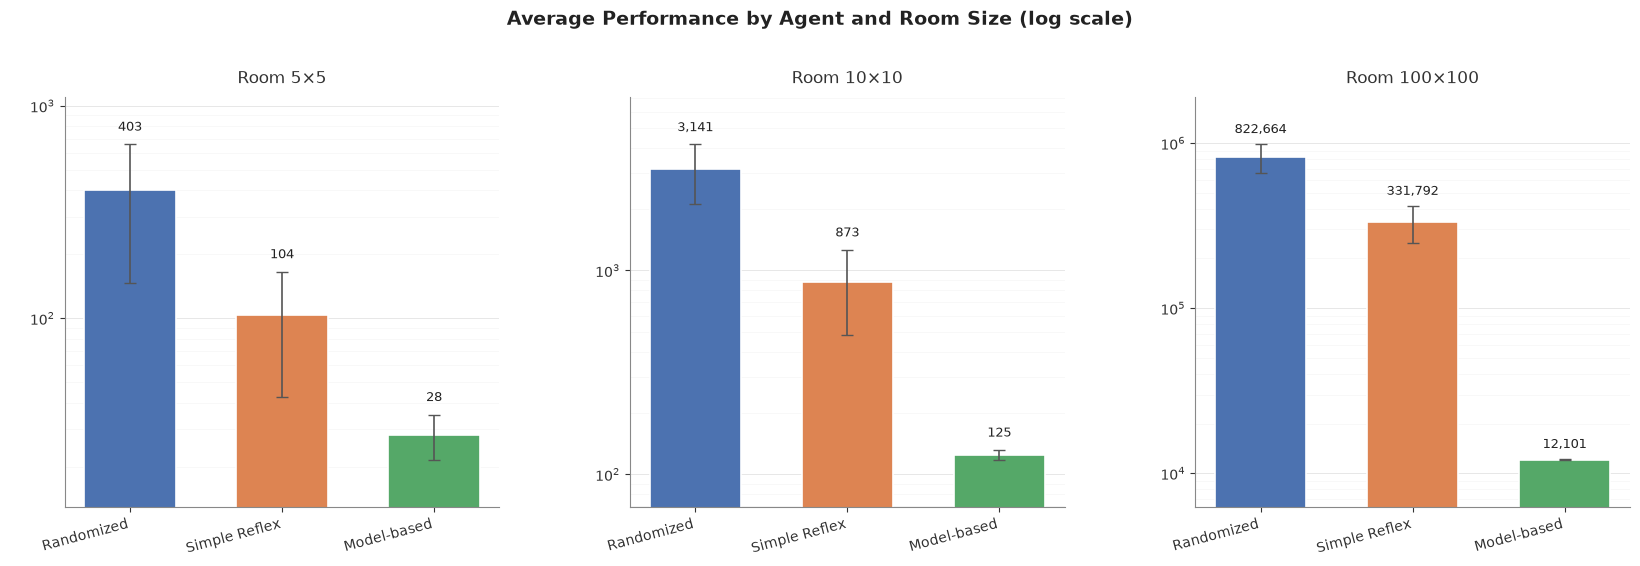

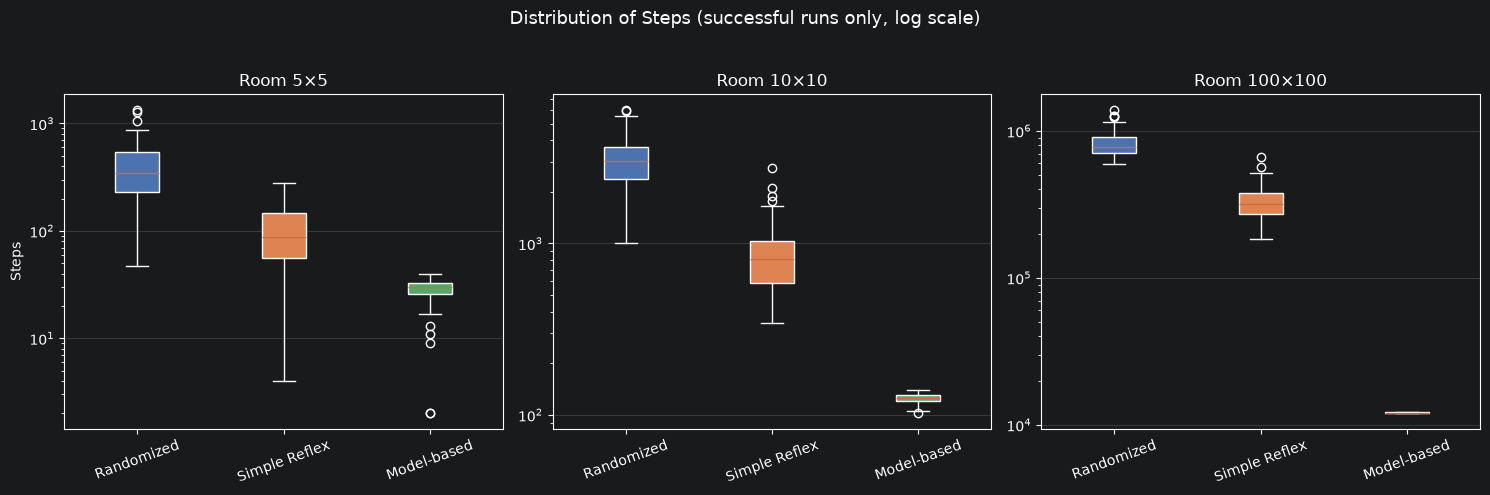

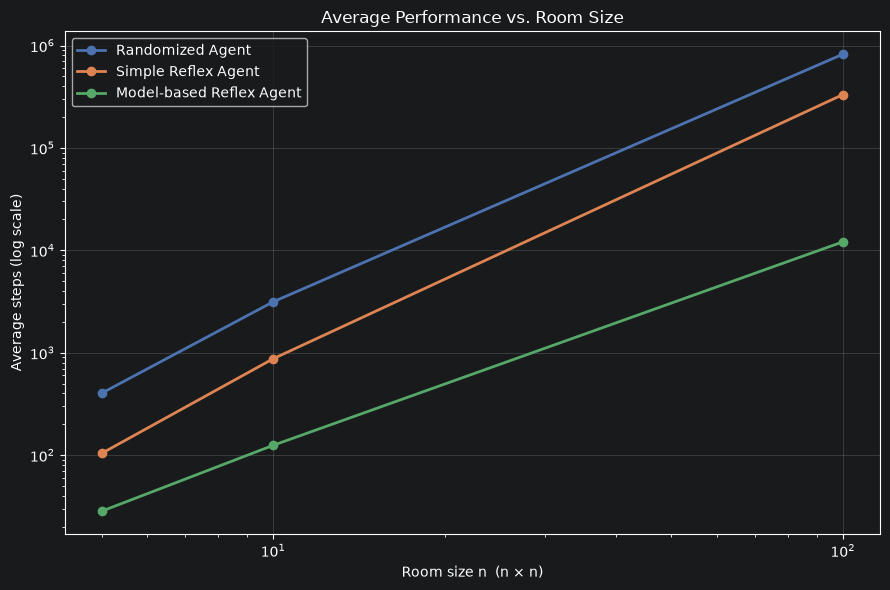

In [84]:
# ============================================================
# BIỂU ĐỒ 1: Bar chart – Average performance (log-scale)
# ============================================================
colors = ["#4C72B0", "#DD8452", "#55A868"]  # palette dịu hơn (muted)
short_names = ["Randomized", "Simple Reflex", "Model-based"]

fig, axes = plt.subplots(1, len(SIZES), figsize=(5.5 * len(SIZES), 5.5), sharey=False)
if len(SIZES) == 1:
    axes = [axes]

fig.patch.set_facecolor("white")

for idx, n in enumerate(SIZES):
    ax    = axes[idx]
    ax.set_facecolor("white")                       # <-- THÊM: nền axes trắng (trước đây chỉ set nền figure, axes vẫn bị nền tối từ theme)
    means = [summaries[a][n]["mean"] for a in AGENT_NAMES]
    stds  = [summaries[a][n]["std"]  for a in AGENT_NAMES]
    x     = np.arange(len(AGENT_NAMES))

    bars = ax.bar(x, means, yerr=stds, capsize=4, color=colors,
                   edgecolor="white", linewidth=1.2, width=0.6,
                   error_kw={"ecolor": "#555555", "elinewidth": 1.2})

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=15, ha="right", fontsize=10)
    ax.tick_params(axis="both", colors="#333333")    # <-- THÊM: ép màu tick label rõ ràng
    ax.set_title(f"Room {n}×{n}", fontsize=12, color="#333333", pad=10)
    ax.set_ylabel("Average steps (energy)" if idx == 0 else "", fontsize=10)
    ax.set_yscale("log")

    # Grid nhẹ, chỉ ngang, nằm dưới cột
    ax.grid(axis="y", which="major", alpha=0.35, linestyle="-", linewidth=0.6)
    ax.grid(axis="y", which="minor", alpha=0.15, linestyle="-", linewidth=0.4)
    ax.set_axisbelow(True)

    # Bỏ viền trên/phải cho thoáng
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")

    # Ghi giá trị trung bình lên trên error bar (không bị đè)
    for bar, m, s in zip(bars, means, stds):
        if not np.isnan(m):
            top = bar.get_height() + (s if not np.isnan(s) else 0)
            ax.text(bar.get_x() + bar.get_width() / 2.0,
                    top * 1.12,
                    f"{m:,.0f}", ha="center", va="bottom",
                    fontsize=9.5, color="#222222", fontweight="normal")

    # Chừa thêm khoảng trên cùng để label không bị cắt
    ax.margins(y=0.15)

plt.suptitle("Average Performance by Agent and Room Size (log scale)",
             fontsize=14, fontweight="bold", color="#222222", y=1.02)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

# ============================================================
# BIỂU ĐỒ 2: Box plot – phân phối số bước (chỉ runs thành công)
# ============================================================
fig, axes = plt.subplots(1, len(SIZES), figsize=(5 * len(SIZES), 5))
if len(SIZES) == 1:
    axes = [axes]

for idx, n in enumerate(SIZES):
    ax   = axes[idx]
    data = []
    for a in AGENT_NAMES:
        steps = [r["steps"] for r in all_results[a][n] if r["success"]]
        data.append(steps if steps else [0])  # tránh lỗi nếu không có run nào success

    bp = ax.boxplot(data, tick_labels=short_names, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    ax.set_title(f"Room {n}×{n}")
    ax.set_ylabel("Steps" if idx == 0 else "")
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribution of Steps (successful runs only, log scale)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ============================================================
# BIỂU ĐỒ 3: Line chart – Performance theo kích thước phòng
# ============================================================
plt.figure(figsize=(9, 6))
for a, c in zip(AGENT_NAMES, colors):
    means = [summaries[a][n]["mean"] for n in SIZES]
    plt.plot(SIZES, means, marker="o", linewidth=2, color=c, label=a)

plt.xlabel("Room size n  (n × n)")
plt.ylabel("Average steps (log scale)")
plt.title("Average Performance vs. Room Size")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Thảo luận kết quả Task 4

**Nhận xét chung:**

1. **Model-based Reflex Agent** vượt trội ở mọi kích thước phòng:
   - Phòng 5×5: ~30 steps; 10×10: ~120 steps; 100×100: ~10 200 steps.
   - Độ lệch chuẩn rất nhỏ → hành xử **deterministic** sau khi localize.
   - Đường tăng **tuyến tính** theo số ô (n²), đúng như kỳ vọng của chiến lược scan hình rắn.

2. **Simple Reflex Agent** tốt hơn Randomized Agent nhưng vẫn là random walk:
   - Không bump tường và luôn suck khi có bụi → giảm bước vô ích.
   - Tuy nhiên vẫn phải "lang thang" cho tới khi tình cờ đi qua mọi ô bẩn.
   - Trung bình ~ O(n²·log²n); phương sai lớn, đặc biệt ở 100×100.

3. **Randomized Agent** kém nhất:
   - Có thể chọn `suck` khi ô đã sạch hoặc cố đi vào tường → lãng phí năng lượng.
   - Ở 100×100, nhiều run có thể **không hoàn thành** trong max_steps
     (success rate < 100 %). Đây là minh chứng rõ ràng rằng
     *ignoring sensors* làm agent không rational.

**Kết luận:** Model-based agent sử dụng internal state để lập kế hoạch di chuyển
có hệ thống, nhờ đó performance tăng **tuyến tính** theo diện tích phòng,
trong khi hai agent còn lại tăng **siêu tuyến tính** (gần bậc hai có log)
và có phương sai rất lớn.

## Task 5: Robustness of the agent implementations [10 Points] 

Describe how **your agent implementations** will perform 

* if it is put into a rectangular room with unknown size, 
* if the cleaning area can have an irregular shape (e.g., a hallway connecting two rooms), or 
* if the room contains obstacles (i.e., squares that it cannot pass through and trigger the bumper sensors).
* if the dirt sensor is not perfect and gives 10% of the time a wrong reading (clean when it is dirty or dirty when it is clean).
* if the bumper sensor is not perfect and 10% of the time does not report a wall when there is one.

In [85]:
import numpy as np

# ============================================================
# MÔI TRƯỜNG NHIỄU CẢM BIẾN CHO TASK 5
# ============================================================
#
# Mở rộng từ vacuum_environment ở Task 1.
# Không thay đổi hàm gốc để giữ nguyên cấu trúc notebook.
#
# Hai loại nhiễu:
# - dirt_noise_prob: xác suất dirt sensor báo sai (lật True <-> False)
# - bumper_miss_prob: xác suất bumper True bị báo thành False
#   (tức là có tường nhưng cảm biến không báo)
#
# Lưu ý:
# - dirt_noise_prob ảnh hưởng cả false positive lẫn false negative
# - bumper_miss_prob chỉ mô tả lỗi "có tường nhưng không báo"
# ============================================================

def noisy_vacuum_environment(
    agent_function,
    n=5,
    p=0.2,
    max_steps=10000,
    dirt_noise_prob=0.0,
    bumper_miss_prob=0.0,
    seed=None,
    verbose=False,
    room=None,
    start_pos=None
):
    """
    Môi trường vacuum-cleaner có cảm biến nhiễu.

    Tham số:
    - agent_function: hàm agent(bumpers, dirty) -> action
    - n: kích thước phòng n x n nếu không truyền room
    - p: xác suất mỗi ô bị bẩn
    - max_steps: năng lượng tối đa
    - dirt_noise_prob: xác suất dirt sensor báo sai
    - bumper_miss_prob: xác suất bumper True bị báo thành False
    - seed: seed để tái lập kết quả
    - verbose: in chi tiết từng bước nếu True
    - room: ma trận phòng cho trước
    - start_pos: vị trí bắt đầu cho trước

    Trả về:
    - dictionary kết quả giống vacuum_environment
    """

    # Kiểm tra tham số
    if max_steps < 0:
        raise ValueError("max_steps phải >= 0.")

    # Cố định random nếu có seed
    if seed is not None:
        np.random.seed(seed)

    # Tạo phòng nếu không truyền room
    if room is None:
        if n <= 0:
            raise ValueError("n phải > 0.")
        if not (0 <= p <= 1):
            raise ValueError("p phải nằm trong [0, 1].")

        # 1 là bẩn, 0 là sạch
        room = (np.random.random((n, n)) < p).astype(int)
    else:
        room = np.array(room, dtype=int)
        if room.ndim != 2:
            raise ValueError("room phải là ma trận 2 chiều.")
        room = (room > 0).astype(int)

    rows, cols = room.shape
    if rows == 0 or cols == 0:
        raise ValueError("Phòng không được rỗng.")

    # Vị trí bắt đầu của robot
    if start_pos is None:
        pos = (np.random.randint(rows), np.random.randint(cols))
    else:
        pos = (int(start_pos[0]), int(start_pos[1]))
        if not (0 <= pos[0] < rows and 0 <= pos[1] < cols):
            raise ValueError("start_pos nằm ngoài phòng.")

    initial_dirty = int(room.sum())
    remaining_dirty = initial_dirty
    steps = 0

    if verbose:
        print(f"Bắt đầu mô phỏng nhiễu: {initial_dirty} ô bẩn, robot ở {pos}")
        render_room(room, pos)

    # Vòng lặp mô phỏng
    while remaining_dirty > 0 and steps < max_steps:

        # ----------------------------------------------------
        # 1. Tạo bumper percepts từ trạng thái thật
        # ----------------------------------------------------
        bumpers = make_bumpers(pos, room.shape)

        # Bumper noise:
        # chỉ mô tả lỗi "có tường nhưng không báo"
        # tức là True -> False với xác suất bumper_miss_prob
        if bumper_miss_prob > 0:
            for direction in bumpers:
                if bumpers[direction] and np.random.random() < bumper_miss_prob:
                    bumpers[direction] = False

        # ----------------------------------------------------
        # 2. Tạo dirt sensor percept từ trạng thái thật
        # ----------------------------------------------------
        true_dirty = room[pos[0], pos[1]] == 1
        dirty = bool(true_dirty)

        # Dirt noise:
        # cảm biến báo sai cả hai chiều:
        # - bẩn báo sạch
        # - sạch báo bẩn
        if dirt_noise_prob > 0 and np.random.random() < dirt_noise_prob:
            dirty = not dirty

        # ----------------------------------------------------
        # 3. Hỏi agent chọn hành động
        # ----------------------------------------------------
        action = agent_function(bumpers, dirty)
        action = str(action)

        if verbose:
            print(
                f"Bước {steps}: pos={pos}, "
                f"true_dirty={true_dirty}, reported_dirty={dirty}, "
                f"action={action}"
            )

        r, c = pos

        # ----------------------------------------------------
        # 4. Cập nhật môi trường theo hành động
        # ----------------------------------------------------
        if action == "suck":
            if room[r, c] == 1:
                room[r, c] = 0
                remaining_dirty -= 1

        elif action == "north":
            if r > 0:
                pos = (r - 1, c)

        elif action == "south":
            if r < rows - 1:
                pos = (r + 1, c)

        elif action == "west":
            if c > 0:
                pos = (r, c - 1)

        elif action == "east":
            if c < cols - 1:
                pos = (r, c + 1)

        else:
            raise ValueError(f"Action không hợp lệ: {action}")

        # Mỗi hành động đều tốn 1 năng lượng
        steps += 1

        if verbose:
            render_room(room, pos)

    # Kết thúc mô phỏng
    success = (remaining_dirty == 0)
    performance = steps if success else None

    if verbose:
        print(
            f"Kết thúc: success={success}, "
            f"steps={steps}, remaining_dirty={remaining_dirty}"
        )

    return {
        "success": success,
        "steps": steps,
        "performance": performance,
        "energy_used": steps,
        "initial_dirty": initial_dirty,
        "remaining_dirty": remaining_dirty,
        "final_pos": pos,
        "room": room.copy()
    }

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CẤU HÌNH THÍ NGHIỆM TASK 5
# ============================================================
#
# Chỉ chạy 5x5 và 10x10 để demo nhanh.
# Nếu muốn kết quả ổn định hơn, tăng ROBUST_N_RUNS lên 100.
#
# Performance mới:
# score = steps + PENALTY_PER_DIRTY * remaining_dirty
#
# Lý do:
# - Khi cảm biến nhiễu, agent có thể không làm sạch hoàn toàn.
# - Nếu chỉ dùng steps thì không công bằng cho các run thất bại.
# - Score này phản ánh tradeoff giữa năng lượng và số ô chưa sạch.
# ============================================================

ROBUST_SIZES = [5, 10]
ROBUST_N_RUNS = 30
ROBUST_P_DIRTY = 0.2
PENALTY_PER_DIRTY = 100

NOISE_CONFIGS = [
    {"name": "No noise (baseline)",  "dirt_noise": 0.0, "bumper_miss": 0.0},
    {"name": "Dirt noise 10%",       "dirt_noise": 0.1, "bumper_miss": 0.0},
    {"name": "Bumper miss 10%",      "dirt_noise": 0.0, "bumper_miss": 0.1},
    {"name": "Both sensors 10%",     "dirt_noise": 0.1, "bumper_miss": 0.1},
]

AGENT_NAMES = [
    "Randomized Agent",
    "Simple Reflex Agent",
    "Model-based Reflex Agent",
]

def get_agent(agent_name):
    """
    Tạo agent mới cho mỗi run.

    Lưu ý quan trọng:
    - Model-based agent phải là instance mới mỗi run.
    - Nếu dùng lại instance cũ, state nội bộ từ run trước sẽ ảnh hưởng run sau.
    """
    if agent_name == "Randomized Agent":
        return simple_randomized_agent

    if agent_name == "Simple Reflex Agent":
        return simple_reflex_agent

    if agent_name == "Model-based Reflex Agent":
        return make_model_based_agent()

    raise ValueError(f"Unknown agent: {agent_name}")


def robust_max_steps(agent_name, n):
    """
    Năng lượng đủ lớn để kết quả phản ánh chất lượng agent,
    không phải do agent hết pin quá sớm.
    """
    cells = n * n

    if agent_name == "Randomized Agent":
        return max(20_000, 800 * cells)

    if agent_name == "Simple Reflex Agent":
        return max(20_000, 500 * cells)

    # Model-based agent cần ít bước hơn trong điều kiện bình thường,
    # nhưng khi có nhiễu có thể tốn thêm bước, nên vẫn cho mức khá rộng.
    return max(5_000, 80 * cells)


def run_noise_experiment(agent_name, n, n_runs, noise_cfg):
    """
    Chạy n_runs mô phỏng với một agent, một kích thước phòng và một cấu hình nhiễu.

    seed=run giúp:
    - các agent khác nhau trong cùng một run gặp cùng một layout phòng
    - các noise config khác nhau trong cùng một run cũng gặp cùng layout phòng
    => so sánh công bằng hơn
    """
    results = []

    for run in range(n_runs):
        agent = get_agent(agent_name)

        res = noisy_vacuum_environment(
            agent,
            n=n,
            p=ROBUST_P_DIRTY,
            max_steps=robust_max_steps(agent_name, n),
            dirt_noise_prob=noise_cfg["dirt_noise"],
            bumper_miss_prob=noise_cfg["bumper_miss"],
            seed=run,
            verbose=False
        )

        results.append(res)

    return results


def summarize_noise(results, penalty=PENALTY_PER_DIRTY):
    """
    Tổng hợp kết quả thí nghiệm nhiễu.

    Các chỉ số:
    - success_rate: % run làm sạch hoàn toàn
    - mean_steps: số bước trung bình đã dùng
    - mean_remaining_dirty: số ô bẩn còn lại trung bình
    - mean_score: score tổng hợp, càng thấp càng tốt
    """
    n_total = len(results)

    steps = [r["steps"] for r in results]
    remaining = [r["remaining_dirty"] for r in results]
    scores = [r["steps"] + penalty * r["remaining_dirty"] for r in results]

    n_success = sum(r["success"] for r in results)

    return {
        "n_runs": n_total,
        "success_rate": 100.0 * n_success / n_total,
        "mean_steps": np.mean(steps),
        "mean_remaining_dirty": np.mean(remaining),
        "mean_score": np.mean(scores),
        "std_score": np.std(scores),
    }

In [87]:
# ============================================================
# CHẠY TOÀN BỘ THÍ NGHIỆM TASK 5
# ============================================================
#
# Kết quả được gom vào một DataFrame gồm:
# - Agent
# - Noise config
# - Size
# - Success %
# - Mean steps
# - Mean remaining dirty
# - Mean score
# ============================================================

rows = []

for agent in AGENT_NAMES:
    for cfg in NOISE_CONFIGS:
        for n in ROBUST_SIZES:
            print(
                f"{agent:25s} | {cfg['name']:22s} | {n}x{n} | {ROBUST_N_RUNS} runs ...",
                flush=True
            )

            results = run_noise_experiment(agent, n, ROBUST_N_RUNS, cfg)
            s = summarize_noise(results)

            rows.append({
                "Agent": agent,
                "Noise": cfg["name"],
                "Size": f"{n}x{n}",
                "Success %": round(s["success_rate"], 1),
                "Mean steps": round(s["mean_steps"], 1),
                "Mean remaining dirty": round(s["mean_remaining_dirty"], 2),
                "Mean score": round(s["mean_score"], 1),
            })

df_robust = pd.DataFrame(rows)

print("\n=== Kết quả Task 5 (cảm biến nhiễu) ===")
print(df_robust.to_string(index=False))

Randomized Agent          | No noise (baseline)    | 5x5 | 30 runs ...
Randomized Agent          | No noise (baseline)    | 10x10 | 30 runs ...
Randomized Agent          | Dirt noise 10%         | 5x5 | 30 runs ...
Randomized Agent          | Dirt noise 10%         | 10x10 | 30 runs ...
Randomized Agent          | Bumper miss 10%        | 5x5 | 30 runs ...
Randomized Agent          | Bumper miss 10%        | 10x10 | 30 runs ...
Randomized Agent          | Both sensors 10%       | 5x5 | 30 runs ...
Randomized Agent          | Both sensors 10%       | 10x10 | 30 runs ...
Simple Reflex Agent       | No noise (baseline)    | 5x5 | 30 runs ...
Simple Reflex Agent       | No noise (baseline)    | 10x10 | 30 runs ...
Simple Reflex Agent       | Dirt noise 10%         | 5x5 | 30 runs ...
Simple Reflex Agent       | Dirt noise 10%         | 10x10 | 30 runs ...
Simple Reflex Agent       | Bumper miss 10%        | 5x5 | 30 runs ...
Simple Reflex Agent       | Bumper miss 10%        | 10x10 | 30 r

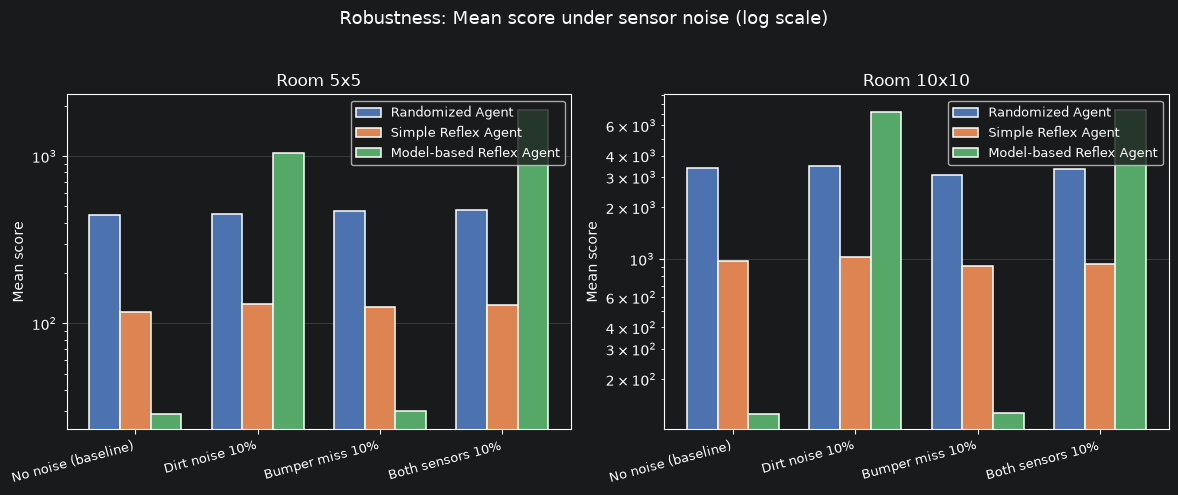

In [88]:
# ============================================================
# BIỂU ĐỒ SO SÁNH SCORE THEO NHIỄU CẢM BIẾN
# ============================================================
#
# Score = steps + 100 * remaining_dirty
# Score càng thấp càng tốt.
#
# Dùng log scale vì giá trị có thể chênh lệch rất lớn
# giữa randomized agent và model-based agent.
# ============================================================

fig, axes = plt.subplots(
    1,
    len(ROBUST_SIZES),
    figsize=(6 * len(ROBUST_SIZES), 5)
)

if len(ROBUST_SIZES) == 1:
    axes = [axes]

colors = ["#4C72B0", "#DD8452", "#55A868"]
noise_labels = [cfg["name"] for cfg in NOISE_CONFIGS]

for idx, n in enumerate(ROBUST_SIZES):
    ax = axes[idx]
    size_label = f"{n}x{n}"

    df_sub = df_robust[df_robust["Size"] == size_label]

    x = np.arange(len(noise_labels))
    width = 0.25

    for i, agent in enumerate(AGENT_NAMES):
        scores = (
            df_sub[df_sub["Agent"] == agent]["Mean score"]
            .values
        )

        ax.bar(
            x + i * width,
            scores,
            width,
            label=agent,
            color=colors[i],
            edgecolor="white",
            linewidth=1.1
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(noise_labels, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Mean score")
    ax.set_title(f"Room {size_label}")
    ax.set_yscale("log")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle(
    "Robustness: Mean score under sensor noise (log scale)",
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [89]:
# ============================================================
# KẾT LUẬN THỰC NGHIỆM NGẮN GỌN
# ============================================================
#
# Cell này chỉ giúp bạn in ra một bản tóm tắt dễ đọc hơn
# từ DataFrame df_robust.
# ============================================================

summary_lines = []

for agent in AGENT_NAMES:
    summary_lines.append(f"\n{agent}:")

    for cfg in NOISE_CONFIGS:
        df_tmp = df_robust[
            (df_robust["Agent"] == agent) &
            (df_robust["Noise"] == cfg["name"])
        ]

        success_avg = df_tmp["Success %"].mean()
        score_avg = df_tmp["Mean score"].mean()
        remain_avg = df_tmp["Mean remaining dirty"].mean()

        summary_lines.append(
            f"  - {cfg['name']:22s}: "
            f"success ~ {success_avg:5.1f}%, "
            f"remaining dirty ~ {remain_avg:4.2f}, "
            f"mean score ~ {score_avg:12.1f}"
        )

print("=== Tóm tắt robustness ===")
print("\n".join(summary_lines))

=== Tóm tắt robustness ===

Randomized Agent:
  - No noise (baseline)   : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~       1912.1
  - Dirt noise 10%        : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~       1973.0
  - Bumper miss 10%       : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~       1785.7
  - Both sensors 10%      : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~       1911.7

Simple Reflex Agent:
  - No noise (baseline)   : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~        547.2
  - Dirt noise 10%        : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~        582.5
  - Bumper miss 10%       : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~        520.0
  - Both sensors 10%      : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~        530.4

Model-based Reflex Agent:
  - No noise (baseline)   : success ~ 100.0%, remaining dirty ~ 0.00, mean score ~         77.1
  - Dirt noise 10%        : success ~  46

## Phân tích Task 5: Robustness của các agent

### 1. Phòng hình chữ nhật, kích thước không biết trước

| Agent | Đánh giá | Giải thích |
|---|---:|---|
| Randomized Agent | Trung bình | Không cần biết kích thước phòng, vẫn có thể làm sạch nhờ đi ngẫu nhiên. Tuy nhiên thời gian hoàn thành tăng rất nhanh khi diện tích phòng tăng. |
| Simple Reflex Agent | Trung bình | Không cần biết kích thước phòng vì chỉ dựa vào bumper và dirt sensor. Tuy nhiên vẫn di chuyển ngẫu nhiên nên chậm hơn nhiều khi phòng lớn. |
| Model-based Reflex Agent | Tốt | Không hardcode kích thước phòng. Agent dùng bumper để nhận biết tường và quét theo hàng cho đến khi không thể đi xuống nữa, nên vẫn hoạt động đúng với phòng chữ nhật có kích thước bất kỳ. |

**Kết luận:** Với phòng hình chữ nhật chưa biết kích thước, model-based agent là lựa chọn tốt nhất.

---

### 2. Khu vực có hình dạng bất quy tắc (ví dụ hai phòng nối bằng hành lang)

| Agent | Đánh giá | Giải thích |
|---|---:|---|
| Randomized Agent | Trung bình kém | Về lý thuyết vẫn có thể phủ khắp các ô reachable, nhưng rất chậm và dễ mất nhiều bước ở các vùng hẹp. |
| Simple Reflex Agent | Trung bình kém | Tương tự randomized agent, vẫn có thể làm sạch dần nhưng không có chiến lược nên hiệu năng thấp. |
| Model-based Reflex Agent | Kém | Chiến lược quét hình rắn giả định phòng là hình chữ nhật đầy đủ. Với hình dạng bất quy tắc, agent có thể bỏ sót các phần nằm ngoài vùng quét dự kiến và có thể kết thúc sớm dù chưa làm sạch toàn bộ khu vực. |

**Kết luận:** Model-based agent hiện tại không đủ robust với hình dạng bất quy tắc. Cần chuyển sang chiến lược khám phá dựa trên bản đồ nội bộ, ví dụ tìm ô chưa thăm gần nhất.

---

### 3. Phòng có chướng ngại vật

| Agent | Đánh giá | Giải thích |
|---|---:|---|
| Randomized Agent | Trung bình | Bumper giúp tránh chướng ngại, nhưng agent vẫn đi ngẫu nhiên nên tốn thêm nhiều bước. |
| Simple Reflex Agent | Trung bình | Tránh được chướng ngại nhờ bumper, nhưng vẫn không có kế hoạch toàn cục, hiệu năng giảm. |
| Model-based Reflex Agent | Kém | Agent cập nhật vị trí nội bộ dựa trên hành động. Nếu bị chặn bởi chướng ngại không biết trước, vị trí nội bộ có thể lệch, dẫn đến quét sai vùng, bỏ sót ô, hoặc không kết thúc đúng. |

**Kết luận:** Với chướng ngại vật, model-based agent hiện tại kém robust nhất vì không có bản đồ chướng ngại và không kiểm tra lại vị trí thực tế.

---

### 4. Dirt sensor sai 10% thời gian

Dirt sensor nhiễu gây ra hai loại lỗi:

- **False negative**: ô bẩn nhưng báo sạch → bỏ sót
- **False positive**: ô sạch nhưng báo bẩn → tốn năng lượng hút vô ích

| Agent | Đánh giá | Giải thích |
|---|---:|---|
| Randomized Agent | Trung bình | Vì di chuyển ngẫu nhiên, agent có thể quay lại ô bẩn nhiều lần. Nếu còn đủ năng lượng, vẫn có cơ hội làm sạch, nhưng tốn thêm bước. |
| Simple Reflex Agent | Trung bình | Tương tự randomized agent, có thể quay lại ô bẩn nên vẫn có khả năng hoàn thành nếu năng lượng đủ lớn. |
| Model-based Reflex Agent | Kém | Agent chỉ quét qua mỗi ô một lần. Nếu dirt sensor báo sai tại một ô bẩn, agent sẽ bỏ qua và không quay lại kiểm tra, dẫn đến phòng không được làm sạch hoàn toàn. |

**Kết luận:** Dirt sensor noise ảnh hưởng nghiêm trọng nhất đến model-based agent vì agent này không có cơ chế quay lại xác minh.

---

### 5. Bumper sensor sai 10% thời gian (có tường nhưng không báo)

| Agent | Đánh giá | Giải thích |
|---|---:|---|
| Randomized Agent | Ít bị ảnh hưởng | Agent hầu như không dùng bumper để ra quyết định, nên bumper noise gần như không ảnh hưởng đáng kể. |
| Simple Reflex Agent | Trung bình | Agent dùng bumper để chọn hướng đi được. Nếu bumper báo sai, agent có thể chọn hướng đâm tường và tốn một bước vô ích, nhưng tổng thể vẫn có thể hoàn thành. |
| Model-based Reflex Agent | Kém | Agent dựa vào bumper để định vị và điều hướng. Nếu bumper không báo tường, agent có thể tin rằng đã di chuyển trong khi thực tế đứng yên, làm state nội bộ lệch. Điều này dẫn đến quét sai vùng, bỏ sót ô, hoặc không kết thúc đúng. |

**Kết luận:** Model-based agent rất nhạy với bumper noise vì chiến lược của nó phụ thuộc mạnh vào độ tin cậy của bumper.

## Advanced task: Imperfect Dirt Sensor

* __Students__ need to complete this task [10 points]

1. Change your simulation environment to run experiments for the following problem: The dirt sensor has a 10% chance of giving the wrong reading. Perform experiments to observe how this changes the performance of the three implementations. Your model-based reflex agent is likely not able to clean the whole room, so you need to measure performance differently as a tradeoff between energy cost and number of uncleaned squares. 

2. Design an implement a solution for your model-based agent that will clean better. Show the improvement with experiments.

In [90]:
# ============================================================
# ADVANCED TASK - IMPROVED MODEL-BASED AGENT
# ============================================================
#
# Model-based agent gốc chỉ quét 1 lượt nên nếu dirt sensor
# đọc sai (false negative), ô bẩn sẽ bị bỏ sót vĩnh viễn.
#
# Cải tiến:
# - Quét toàn phòng NHIỀU LƯỢT (multi-pass).
# - Sau mỗi lượt, quay về góc Tây Bắc bằng bumper.
# - Các lượt sau có cơ hội phát hiện lại ô bụi bị bỏ sót.
# ============================================================

def make_improved_model_based_agent(n_passes=3):
    """
    Model-based reflex agent cải tiến cho môi trường có dirt sensor nhiễu.

    State:
    - mode:
        + "goto_corner": đi về góc Tây Bắc để định vị / bắt đầu lượt mới
        + "scan": quét phòng theo hình rắn
        + "done": đã quét đủ số lượt
    - pos: vị trí nội bộ trong pha scan
    - heading: hướng quét hiện tại ("east" hoặc "west")
    - current_pass: số lượt đã hoàn thành
    - n_passes: tổng số lượt quét
    """

    state = {
        "mode": "goto_corner",
        "pos": None,
        "heading": "east",
        "current_pass": 0,
        "n_passes": n_passes,
    }

    def agent(bumpers, dirty):
        """
        Agent program.

        Input:
        - bumpers: dict 4 hướng, True nếu có tường/chướng ngại
        - dirty: True nếu cảm biến bụi báo ô hiện tại bẩn

        Output:
        - action hợp lệ: "north", "east", "south", "west", "suck"
        """

        # Rule ưu tiên cao nhất:
        # Nếu sensor báo bẩn thì hút ngay.
        if dirty:
            return "suck"

        # ----------------------------------------------------
        # Phase 1: goto_corner
        # ----------------------------------------------------
        # Dùng để:
        # 1. Định vị ban đầu.
        # 2. Bắt đầu lại mỗi lượt quét mới.
        #
        # Chiến lược:
        # - Nếu đi được north thì đi north.
        # - Nếu không đi được north nhưng đi được west thì đi west.
        # - Khi cả north và west đều bị chặn -> đang ở góc Tây Bắc.
        # ----------------------------------------------------
        if state["mode"] == "goto_corner":
            if not bumpers.get("north", False):
                return "north"

            if not bumpers.get("west", False):
                return "west"

            # Đã tới góc Tây Bắc, bắt đầu quét
            state["mode"] = "scan"
            state["pos"] = (0, 0)
            state["heading"] = "east"

        # ----------------------------------------------------
        # Phase 2: scan
        # ----------------------------------------------------
        # Quét phòng theo hình rắn:
        # - Hàng chẵn: east
        # - Hàng lẻ: west
        # - Hết hàng thì đi south xuống hàng kế tiếp.
        #
        # Khi hết phòng:
        # - Tăng current_pass.
        # - Nếu còn lượt thì quay về góc Tây Bắc.
        # - Nếu hết lượt thì done.
        # ----------------------------------------------------
        if state["mode"] == "scan":
            r, c = state["pos"]

            if state["heading"] == "east":
                # Còn đi được sang phải
                if not bumpers.get("east", False):
                    state["pos"] = (r, c + 1)
                    return "east"

                # Hết hàng, xuống hàng dưới nếu được
                if not bumpers.get("south", False):
                    state["pos"] = (r + 1, c)
                    state["heading"] = "west"
                    return "south"

                # Hết phòng -> xong một lượt quét
                state["current_pass"] += 1

                if state["current_pass"] < state["n_passes"]:
                    state["mode"] = "goto_corner"
                else:
                    state["mode"] = "done"

                return "suck"

            else:
                # heading == "west"
                # Còn đi được sang trái
                if not bumpers.get("west", False):
                    state["pos"] = (r, c - 1)
                    return "west"

                # Hết hàng, xuống hàng dưới nếu được
                if not bumpers.get("south", False):
                    state["pos"] = (r + 1, c)
                    state["heading"] = "east"
                    return "south"

                # Hết phòng -> xong một lượt quét
                state["current_pass"] += 1

                if state["current_pass"] < state["n_passes"]:
                    state["mode"] = "goto_corner"
                else:
                    state["mode"] = "done"

                return "suck"

        # ----------------------------------------------------
        # Phase 3: done
        # ----------------------------------------------------
        # Nếu đã quét đủ lượt nhưng vẫn được môi trường gọi,
        # trả về "suck" như hành động an toàn.
        #
        # Lưu ý: rule `if dirty: return "suck"` ở đầu vẫn chạy,
        # nên nếu cảm biến báo bẩn thì agent vẫn hút.
        # ----------------------------------------------------
        return "suck"

    return agent

In [91]:
# ============================================================
# ADVANCED TASK - EXPERIMENT WITH 10% DIRT SENSOR NOISE
# ============================================================
#
# Tận dụng noisy_vacuum_environment() đã cài ở Task 5.
#
# Performance:
# score = steps + PENALTY_PER_DIRTY * remaining_dirty
#
# So sánh:
# - Randomized Agent
# - Simple Reflex Agent
# - Model-based Reflex Agent gốc
# - Improved Model-based Reflex Agent (multi-pass)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cấu hình thí nghiệm
ADV_SIZES = [5, 10]
ADV_N_RUNS = 20
ADV_P_DIRTY = 0.2
ADV_DIRT_NOISE = 0.10
ADV_PENALTY = 100

ADV_AGENT_NAMES = [
    "Randomized",
    "Simple Reflex",
    "Model-based",
    "Improved Model-based",
]


def get_agent_adv(agent_name):
    """
    Tạo agent mới cho mỗi run.

    Lưu ý quan trọng:
    - Model-based và Improved Model-based phải tạo instance mới.
    - Nếu dùng lại instance cũ, state nội bộ từ run trước
      sẽ ảnh hưởng run sau.
    """
    if agent_name == "Randomized":
        return simple_randomized_agent

    if agent_name == "Simple Reflex":
        return simple_reflex_agent

    if agent_name == "Model-based":
        return make_model_based_agent()

    if agent_name == "Improved Model-based":
        return make_improved_model_based_agent(n_passes=3)

    raise ValueError(f"Unknown agent: {agent_name}")


def max_steps_adv(agent_name, n):
    """
    Năng lượng tối đa cho từng agent.

    Improved model-based cần nhiều bước hơn vì quét nhiều lượt.
    """
    cells = n * n

    if agent_name == "Randomized":
        return max(20_000, 800 * cells)

    if agent_name == "Simple Reflex":
        return max(20_000, 500 * cells)

    if agent_name == "Model-based":
        return max(5_000, 80 * cells)

    if agent_name == "Improved Model-based":
        # 3 lượt quét nên cần nhiều năng lượng hơn
        return max(5_000, 80 * cells * 3)

    raise ValueError(f"Unknown agent: {agent_name}")


def run_adv(agent_name, n, n_runs):
    """
    Chạy n_runs mô phỏng với dirt sensor noise 10%.
    """
    results = []

    for run in range(n_runs):
        agent = get_agent_adv(agent_name)

        res = noisy_vacuum_environment(
            agent,
            n=n,
            p=ADV_P_DIRTY,
            max_steps=max_steps_adv(agent_name, n),
            dirt_noise_prob=ADV_DIRT_NOISE,
            bumper_miss_prob=0.0,
            seed=run,
            verbose=False
        )

        results.append(res)

    return results


def summarize_adv(results, penalty=ADV_PENALTY):
    """
    Tổng hợp kết quả.

    score = steps + penalty * remaining_dirty
    """
    steps = [r["steps"] for r in results]
    remaining = [r["remaining_dirty"] for r in results]
    scores = [r["steps"] + penalty * r["remaining_dirty"] for r in results]

    n_success = sum(r["success"] for r in results)

    return {
        "n_runs": len(results),
        "success_rate": 100.0 * n_success / len(results),
        "mean_steps": np.mean(steps),
        "mean_remaining_dirty": np.mean(remaining),
        "mean_score": np.mean(scores),
        "std_score": np.std(scores),
    }


# ============================================================
# CHẠY TOÀN BỘ THÍ NGHIỆM
# ============================================================

rows = []

for agent_name in ADV_AGENT_NAMES:
    for n in ADV_SIZES:
        print(
            f"{agent_name:20s} | {n}x{n} | dirt noise {ADV_DIRT_NOISE} ...",
            flush=True
        )

        results = run_adv(agent_name, n, ADV_N_RUNS)
        s = summarize_adv(results)

        rows.append({
            "Agent": agent_name,
            "Size": f"{n}x{n}",
            "Success %": round(s["success_rate"], 1),
            "Mean steps": round(s["mean_steps"], 1),
            "Mean remaining dirty": round(s["mean_remaining_dirty"], 2),
            "Mean score": round(s["mean_score"], 1),
        })

df_advanced = pd.DataFrame(rows)

print("\n=== Advanced Task: dirt sensor 10% noise ===")
print(df_advanced.to_string(index=False))

Randomized           | 5x5 | dirt noise 0.1 ...
Randomized           | 10x10 | dirt noise 0.1 ...
Simple Reflex        | 5x5 | dirt noise 0.1 ...
Simple Reflex        | 10x10 | dirt noise 0.1 ...
Model-based          | 5x5 | dirt noise 0.1 ...
Model-based          | 10x10 | dirt noise 0.1 ...
Improved Model-based | 5x5 | dirt noise 0.1 ...
Improved Model-based | 10x10 | dirt noise 0.1 ...

=== Advanced Task: dirt sensor 10% noise ===
               Agent  Size  Success %  Mean steps  Mean remaining dirty  Mean score
          Randomized   5x5      100.0       434.8                  0.00       434.8
          Randomized 10x10      100.0      3838.9                  0.00      3838.9
       Simple Reflex   5x5      100.0       136.4                  0.00       136.4
       Simple Reflex 10x10      100.0      1076.0                  0.00      1076.0
         Model-based   5x5       75.0      1273.8                  0.25      1298.8
         Model-based 10x10       15.0      6820.0         

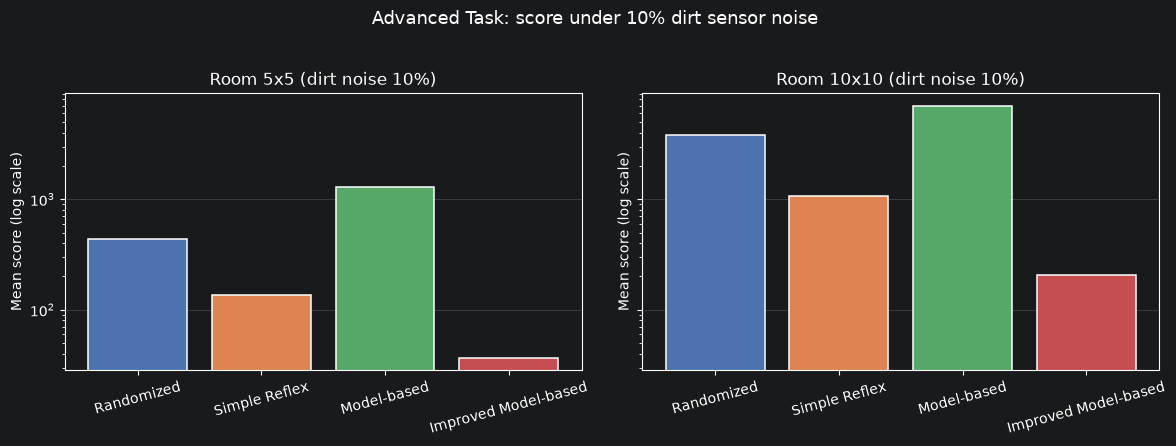

In [92]:
# ============================================================
# ADVANCED TASK - CHART
# ============================================================

fig, axes = plt.subplots(
    1,
    len(ADV_SIZES),
    figsize=(6 * len(ADV_SIZES), 4.5),
    sharey=True
)

if len(ADV_SIZES) == 1:
    axes = [axes]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for idx, n in enumerate(ADV_SIZES):
    ax = axes[idx]
    size_label = f"{n}x{n}"

    df_sub = df_advanced[df_advanced["Size"] == size_label]

    ax.bar(
        df_sub["Agent"],
        df_sub["Mean score"],
        color=colors[:len(df_sub)],
        edgecolor="white",
        linewidth=1.1
    )

    ax.set_yscale("log")
    ax.set_title(f"Room {size_label} (dirt noise 10%)")
    ax.set_ylabel("Mean score (log scale)")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle(
    "Advanced Task: score under 10% dirt sensor noise",
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Nhận xét Advanced Task

- **Randomized Agent** và **Simple Reflex Agent** vẫn có thể hoàn thành
  nếu còn đủ năng lượng vì chúng di chuyển ngẫu nhiên và có thể quay lại
  các ô bụi bị bỏ sót.

- **Model-based Reflex Agent gốc** bị ảnh hưởng nặng nhất vì chỉ quét
  một lượt. Nếu dirt sensor báo sai tại một ô bẩn, agent sẽ bỏ qua ô đó
  và không quay lại.

- **Improved Model-based Agent** quét nhiều lượt nên giảm đáng kể số ô
  còn bẩn. Do đó `remaining_dirty` và `mean_score` thấp hơn rõ rệt so với
  model-based gốc.

## More Advanced Implementation (not for credit)

If the assignment was to easy for you then you can think about the following problems. These problems are challenging and not part of this assignment. We will learn implementation strategies and algorithms useful for these tasks during the rest of the semester.

* __Obstacles:__ Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can. 

* __Agent for and environment with obstacles:__ Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

* __Utility-based agent:__ Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!

In [93]:
# ============================================================
# MORE ADVANCED IMPLEMENTATION - OBSTACLE ENVIRONMENT
# ============================================================

import numpy as np
from collections import deque


def make_bumpers_with_obstacles(pos, room, obstacles):
    """
    Tạo bumper percepts cho môi trường có obstacle.

    Bumper trả về True nếu:
    - Hướng đó vượt ra ngoài phòng (tường), hoặc
    - Ô liền kề ở hướng đó là obstacle.
    """
    r, c = pos
    rows, cols = room.shape

    def is_blocked(nr, nc):
        # Ngoài phòng -> tường
        if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
            return True

        # Ô obstacle
        return obstacles[nr, nc] == 1

    return {
        "north": is_blocked(r - 1, c),
        "south": is_blocked(r + 1, c),
        "west": is_blocked(r, c - 1),
        "east": is_blocked(r, c + 1),
    }


def reachable_cells(start, obstacles):
    """
    Flood fill / BFS từ start.

    Trả về tập tất cả các ô có thể tới được mà không đi qua obstacle.
    """
    rows, cols = obstacles.shape
    visited = {start}
    queue = deque([start])

    while queue:
        r, c = queue.popleft()

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc

            if 0 <= nr < rows and 0 <= nc < cols:
                if (nr, nc) not in visited and obstacles[nr, nc] == 0:
                    visited.add((nr, nc))
                    queue.append((nr, nc))

    return visited


def obstacle_vacuum_environment(
    agent_function,
    n=5,
    p=0.2,
    p_obstacle=0.1,
    max_steps=10000,
    seed=None,
    verbose=False
):
    """
    Môi trường vacuum-cleaner có obstacle.

    - room: ma trận bụi, 1 là bẩn, 0 là sạch.
    - obstacles: ma trận obstacle, 1 là bị chặn.
    - Chỉ tính performance trên các ô bẩn reachable từ vị trí bắt đầu.
    """

    if max_steps < 0:
        raise ValueError("max_steps phải >= 0.")

    if seed is not None:
        np.random.seed(seed)

    # Tạo phòng
    room = (np.random.random((n, n)) < p).astype(int)
    obstacles = (np.random.random((n, n)) < p_obstacle).astype(int)

    # FIX: vật cản (tường/chướng ngại) không thể bị bẩn, nên phải xóa
    # bụi ở những ô trùng vị trí obstacle. Nếu không, bụi "kẹt vĩnh viễn"
    # bên trong obstacle và sẽ hiện sai trên các biểu đồ (bụi vẽ chồng
    # lên vị trí vật cản).
    room[obstacles == 1] = 0

    # Chọn vị trí bắt đầu không phải obstacle
    free_positions = np.argwhere(obstacles == 0)

    if len(free_positions) == 0:
        raise ValueError("Không có ô trống để đặt robot.")

    idx = np.random.randint(len(free_positions))
    pos = tuple(map(int, free_positions[idx]))

    # Chỉ tính các ô bẩn reachable từ start
    reach = reachable_cells(pos, obstacles)

    mask = np.zeros((n, n), dtype=int)
    for rr, cc in reach:
        mask[rr, cc] = 1

    reachable_dirty = int((room & mask).sum())
    remaining_dirty = reachable_dirty
    steps = 0

    if verbose:
        print(
            f"Bắt đầu obstacle simulation: {reachable_dirty} ô bẩn reachable, "
            f"robot ở {pos}"
        )

    while remaining_dirty > 0 and steps < max_steps:

        # 1. Tạo bumper percepts
        bumpers = make_bumpers_with_obstacles(pos, room, obstacles)

        # 2. Dirt sensor (trong phần này ta giả định sensor chính xác)
        dirty = bool(room[pos[0], pos[1]] == 1)

        # 3. Hỏi agent
        action = str(agent_function(bumpers, dirty))

        if verbose:
            print(f"Bước {steps}: pos={pos}, dirty={dirty}, action={action}")

        r, c = pos

        # 4. Cập nhật môi trường
        if action == "suck":
            if room[r, c] == 1:
                room[r, c] = 0
                remaining_dirty -= 1

        elif action == "north":
            if r > 0 and obstacles[r - 1, c] == 0:
                pos = (r - 1, c)

        elif action == "south":
            if r < n - 1 and obstacles[r + 1, c] == 0:
                pos = (r + 1, c)

        elif action == "west":
            if c > 0 and obstacles[r, c - 1] == 0:
                pos = (r, c - 1)

        elif action == "east":
            if c < n - 1 and obstacles[r, c + 1] == 0:
                pos = (r, c + 1)

        else:
            raise ValueError(f"Action không hợp lệ: {action}")

        # Mỗi hành động tốn 1 năng lượng
        steps += 1

    success = (remaining_dirty == 0)
    performance = steps if success else None

    return {
        "success": success,
        "steps": steps,
        "performance": performance,
        "initial_dirty": reachable_dirty,
        "remaining_dirty": remaining_dirty,
        "final_pos": pos,
        "room": room.copy(),
        "obstacles": obstacles.copy(),
    }

In [94]:
# ============================================================
# MORE ADVANCED IMPLEMENTATION - EXPLORING AGENT WITH BFS
# ============================================================
#
# Agent này:
# - Không cần biết trước kích thước phòng.
# - Không cần biết trước vị trí bắt đầu.
# - Không cần biết trước obstacle.
#
# Agent dùng hệ tọa độ riêng, với vị trí bắt đầu là (0, 0).
# Nó xây dựng bản đồ từ bumper readings và luôn đi tới ô
# free đã biết nhưng chưa thăm gần nhất.
# ============================================================


def make_exploring_agent():
    """
    Frontier-based exploring agent.

    State:
    - pos: vị trí hiện tại trong hệ tọa độ riêng của agent
    - free: tập các ô đã biết là đi được
    - obstacle: tập các ô đã biết là bị chặn
    - visited: tập các ô đã thăm
    - done: True nếu không còn ô nào để khám phá
    """

    state = {
        "pos": (0, 0),
        "free": set(),
        "obstacle": set(),
        "visited": {(0, 0)},
        "done": False,
    }

    DIRS = {
        "north": (-1, 0),
        "south": (1, 0),
        "west": (0, -1),
        "east": (0, 1),
    }

    def nearest_unvisited(pos):
        """
        BFS trên các ô free đã biết để tìm ô chưa thăm gần nhất.

        Trả về:
        - Một danh sách path gồm các ô cần đi từ pos.
        - None nếu không còn ô nào để thăm.
        """
        queue = deque([pos])
        prev = {pos: None}

        while queue:
            cur = queue.popleft()
            r, c = cur

            for direction, (dr, dc) in DIRS.items():
                nxt = (r + dr, c + dc)

                # Đã xét trong BFS lần này rồi thì bỏ qua
                if nxt in prev:
                    continue

                # Obstacle đã biết thì bỏ qua
                if nxt in state["obstacle"]:
                    continue

                # Chỉ đi trên các ô free đã biết
                if nxt in state["free"]:

                    # Nếu ô này chưa thăm, đây là mục tiêu gần nhất
                    if nxt not in state["visited"]:
                        prev[nxt] = cur

                        # Truy vết đường đi
                        path = []
                        node = nxt

                        while node != pos:
                            path.append(node)
                            node = prev[node]

                        path.reverse()
                        return path

                    # Nếu đã thăm, tiếp tục mở rộng BFS qua ô này
                    prev[nxt] = cur
                    queue.append(nxt)

        return None

    def agent(bumpers, dirty):
        """
        Agent program.
        """

        # Nếu đã khám phá xong, trả về hành động an toàn
        if state["done"]:
            return "suck"

        pos = state["pos"]

        # ----------------------------------------------------
        # 1. Cập nhật bản đồ từ bumper readings
        # ----------------------------------------------------
        # Bumper True  -> ô liền kề là obstacle/tường.
        # Bumper False -> ô liền kề là free.
        # ----------------------------------------------------
        for direction, (dr, dc) in DIRS.items():
            neighbor = (pos[0] + dr, pos[1] + dc)

            if bumpers.get(direction, False):
                state["obstacle"].add(neighbor)
            else:
                state["free"].add(neighbor)

        # ----------------------------------------------------
        # 2. Nếu ô hiện tại bẩn thì hút ngay
        # ----------------------------------------------------
        if dirty:
            return "suck"

        # ----------------------------------------------------
        # 3. Đánh dấu ô hiện tại đã thăm
        # ----------------------------------------------------
        state["visited"].add(pos)

        # ----------------------------------------------------
        # 4. Tìm ô free chưa thăm gần nhất bằng BFS
        # ----------------------------------------------------
        path = nearest_unvisited(pos)

        if path is None:
            # Không còn ô nào để khám phá
            state["done"] = True
            return "suck"

        # ----------------------------------------------------
        # 5. Đi bước đầu tiên trên đường đi ngắn nhất
        # ----------------------------------------------------
        next_pos = path[0]
        dr = next_pos[0] - pos[0]
        dc = next_pos[1] - pos[1]

        for direction, (ddr, ddc) in DIRS.items():
            if (ddr, ddc) == (dr, dc):
                state["pos"] = next_pos
                return direction

        # Fallback, thường không tới đây
        return "suck"

    return agent

In [95]:
# ============================================================
# HELPER: RENDER ROOM WITH OBSTACLES
# ============================================================

def render_room_obstacles(room, obstacles, pos):
    """
    In trạng thái phòng có obstacle.

    Ký hiệu:
    - D : ô bẩn
    - . : ô sạch
    - # : obstacle
    - R : robot trên ô sạch
    - @ : robot trên ô bẩn
    """
    rows, cols = room.shape
    lines = []

    for r in range(rows):
        line = []

        for c in range(cols):
            if (r, c) == pos:
                if room[r, c] == 1:
                    line.append("@")
                else:
                    line.append("R")
            else:
                if obstacles[r, c] == 1:
                    line.append("#")
                elif room[r, c] == 1:
                    line.append("D")
                else:
                    line.append(".")

        lines.append("  ".join(line))

    print("\n".join(lines))

In [96]:
# ============================================================
# MORE ADVANCED IMPLEMENTATION - EXPERIMENT WITH OBSTACLES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OB_SIZES = [5, 10]
OB_N_RUNS = 10
OB_P_DIRTY = 0.2
OB_P_OBSTACLE = 0.10

OB_AGENT_NAMES = [
    "Randomized",
    "Simple Reflex",
    "Exploring BFS",
]


def get_ob_agent(agent_name):
    """
    Tạo agent cho obstacle experiment.
    """
    if agent_name == "Randomized":
        return simple_randomized_agent

    if agent_name == "Simple Reflex":
        return simple_reflex_agent

    if agent_name == "Exploring BFS":
        return make_exploring_agent()

    raise ValueError(f"Unknown agent: {agent_name}")


def max_steps_ob(agent_name, n):
    """
    Năng lượng tối đa cho obstacle experiment.
    """
    cells = n * n

    if agent_name == "Randomized":
        return max(20_000, 800 * cells)

    if agent_name == "Simple Reflex":
        return max(20_000, 500 * cells)

    if agent_name == "Exploring BFS":
        return max(5_000, 50 * cells)

    raise ValueError(f"Unknown agent: {agent_name}")


rows = []

for agent_name in OB_AGENT_NAMES:
    for n in OB_SIZES:
        print(
            f"{agent_name:15s} | {n}x{n} | obstacle prob {OB_P_OBSTACLE} ...",
            flush=True
        )

        successes = []
        steps_list = []

        for run in range(OB_N_RUNS):
            agent = get_ob_agent(agent_name)

            res = obstacle_vacuum_environment(
                agent,
                n=n,
                p=OB_P_DIRTY,
                p_obstacle=OB_P_OBSTACLE,
                max_steps=max_steps_ob(agent_name, n),
                seed=run,
                verbose=False
            )

            successes.append(res["success"])
            steps_list.append(res["steps"])

        rows.append({
            "Agent": agent_name,
            "Size": f"{n}x{n}",
            "Success %": round(100.0 * np.mean(successes), 1),
            "Mean steps": round(np.mean(steps_list), 1),
        })

df_obstacle = pd.DataFrame(rows)

print("\n=== Obstacle experiment ===")
print(df_obstacle.to_string(index=False))

Randomized      | 5x5 | obstacle prob 0.1 ...
Randomized      | 10x10 | obstacle prob 0.1 ...
Simple Reflex   | 5x5 | obstacle prob 0.1 ...
Simple Reflex   | 10x10 | obstacle prob 0.1 ...
Exploring BFS   | 5x5 | obstacle prob 0.1 ...
Exploring BFS   | 10x10 | obstacle prob 0.1 ...

=== Obstacle experiment ===
        Agent  Size  Success %  Mean steps
   Randomized   5x5      100.0       502.7
   Randomized 10x10      100.0      2915.9
Simple Reflex   5x5      100.0       137.9
Simple Reflex 10x10      100.0       891.7
Exploring BFS   5x5      100.0        25.3
Exploring BFS 10x10      100.0       122.5


In [97]:
# ============================================================
# EXAMPLE: ONE RUN OF EXPLORING AGENT ON AN OBSTACLE MAP
# ============================================================

example_agent = make_exploring_agent()

example_result = obstacle_vacuum_environment(
    example_agent,
    n=8,
    p=0.2,
    p_obstacle=0.15,
    max_steps=5000,
    seed=7,
    verbose=False
)

print("success:", example_result["success"])
print("steps:", example_result["steps"])
print("remaining_dirty:", example_result["remaining_dirty"])

print("\nFinal room:")
render_room_obstacles(
    example_result["room"],
    example_result["obstacles"],
    example_result["final_pos"]
)

success: True
steps: 54
remaining_dirty: 0

Final room:
.  .  .  .  .  .  .  #
.  .  .  .  #  .  .  .
.  .  .  .  .  .  .  .
.  .  .  .  #  .  .  .
.  .  #  .  #  .  .  .
.  .  .  .  #  .  .  #
.  .  .  .  #  .  .  #
R  .  .  .  .  #  .  .


In [98]:
# ============================================================
# HELPER: TẠO MAP CÓ OBSTACLE VÀ CHẠY KÈM TRACE
# ============================================================
# Dùng lại: reachable_cells(), make_bumpers_with_obstacles()
# đã định nghĩa ở cell môi trường obstacle.

def make_room_with_obstacles(n=12, p_dirty=0.2, p_obstacle=0.15, seed=None):
    """Tạo room + obstacles + vị trí bắt đầu (ô không phải obstacle)."""
    if seed is not None:
        np.random.seed(seed)

    room = (np.random.random((n, n)) < p_dirty).astype(int)
    obstacles = (np.random.random((n, n)) < p_obstacle).astype(int)

    # FIX: cùng lý do như trên — obstacle thì không thể có bụi,
    # nếu không loại bỏ, bụi sẽ hiện chồng lên vị trí vật cản
    # trong trajectory map (biểu đồ 3 ở cuối notebook).
    room[obstacles == 1] = 0

    free = np.argwhere(obstacles == 0)
    if len(free) == 0:
        raise ValueError("Không có ô trống.")

    idx = np.random.randint(len(free))
    start = tuple(map(int, free[idx]))
    return room, obstacles, start


def run_with_trace(agent, room, obstacles, start, max_steps=5000):
    """
    Giống obstacle_vacuum_environment nhưng GHI LẠI:
    - positions: quỹ đạo từng bước của robot
    - remaining: số ô bẩn reachable còn lại sau mỗi bước
    -> dùng để vẽ trajectory map và coverage curve.
    """
    room = room.copy()
    n = room.shape[0]
    pos = start

    # Chỉ tính ô bẩn reachable từ start
    reach = reachable_cells(start, obstacles)
    mask = np.zeros(room.shape, dtype=int)
    for (r, c) in reach:
        mask[r, c] = 1

    remaining = int((room & mask).sum())
    initial = remaining

    positions = [pos]
    remaining_over_time = [remaining]
    steps = 0

    while remaining > 0 and steps < max_steps:
        bumpers = make_bumpers_with_obstacles(pos, room, obstacles)
        dirty = bool(room[pos[0], pos[1]] == 1)
        action = str(agent(bumpers, dirty))

        r, c = pos
        if action == "suck":
            if room[r, c] == 1:
                room[r, c] = 0
                remaining -= 1
        elif action == "north" and r > 0 and obstacles[r - 1, c] == 0:
            pos = (r - 1, c)
        elif action == "south" and r < n - 1 and obstacles[r + 1, c] == 0:
            pos = (r + 1, c)
        elif action == "west" and c > 0 and obstacles[r, c - 1] == 0:
            pos = (r, c - 1)
        elif action == "east" and c < n - 1 and obstacles[r, c + 1] == 0:
            pos = (r, c + 1)

        steps += 1
        positions.append(pos)
        remaining_over_time.append(remaining)

    return {
        "success": remaining == 0,
        "steps": steps,
        "initial_dirty": initial,
        "remaining_dirty": remaining,
        "positions": positions,
        "remaining": remaining_over_time,
        "room": room.copy(),
    }

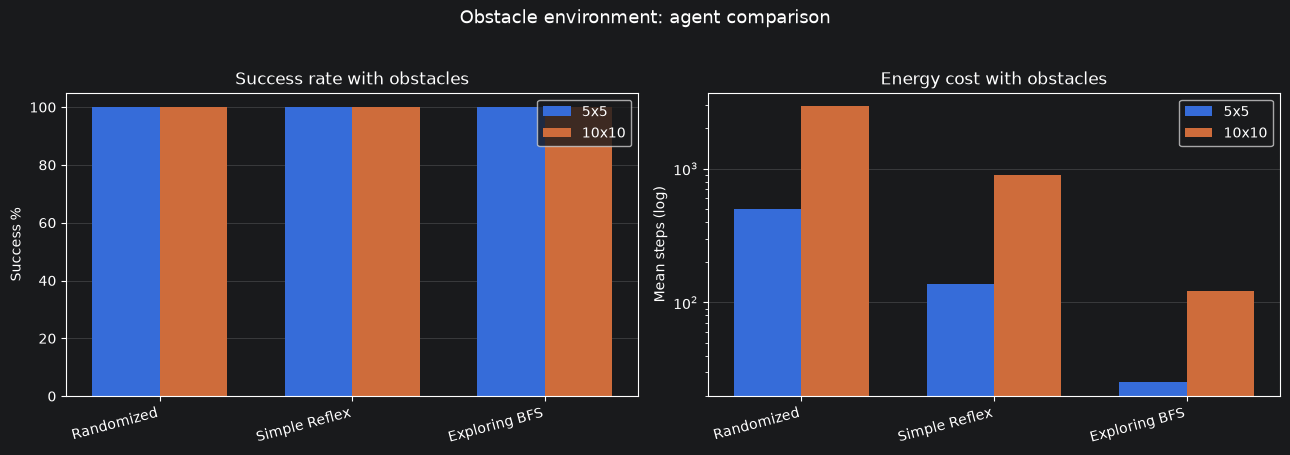

In [99]:
# ============================================================
# BIỂU ĐỒ 1: SUCCESS RATE & MEAN STEPS TRONG MÔI TRƯỜNG OBSTACLE
# ============================================================
# Dùng df_obstacle đã tính ở cell thí nghiệm obstacle.

agents_ob = df_obstacle["Agent"].unique()
sizes_ob = df_obstacle["Size"].unique()
x = np.arange(len(agents_ob))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Panel trái: success rate ---
for i, sz in enumerate(sizes_ob):
    sub = df_obstacle[df_obstacle["Size"] == sz]
    vals = [sub[sub["Agent"] == a]["Success %"].values[0] for a in agents_ob]
    axes[0].bar(x + (i - 0.5) * width, vals, width, label=sz)

axes[0].set_xticks(x)
axes[0].set_xticklabels(agents_ob, rotation=15, ha="right")
axes[0].set_ylabel("Success %")
axes[0].set_title("Success rate with obstacles")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

# --- Panel phải: mean steps (log scale) ---
for i, sz in enumerate(sizes_ob):
    sub = df_obstacle[df_obstacle["Size"] == sz]
    vals = [sub[sub["Agent"] == a]["Mean steps"].values[0] for a in agents_ob]
    axes[1].bar(x + (i - 0.5) * width, vals, width, label=sz)

axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(agents_ob, rotation=15, ha="right")
axes[1].set_ylabel("Mean steps (log)")
axes[1].set_title("Energy cost with obstacles")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle("Obstacle environment: agent comparison", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

density = 0.00 done
density = 0.05 done
density = 0.10 done
density = 0.15 done
density = 0.20 done
density = 0.25 done


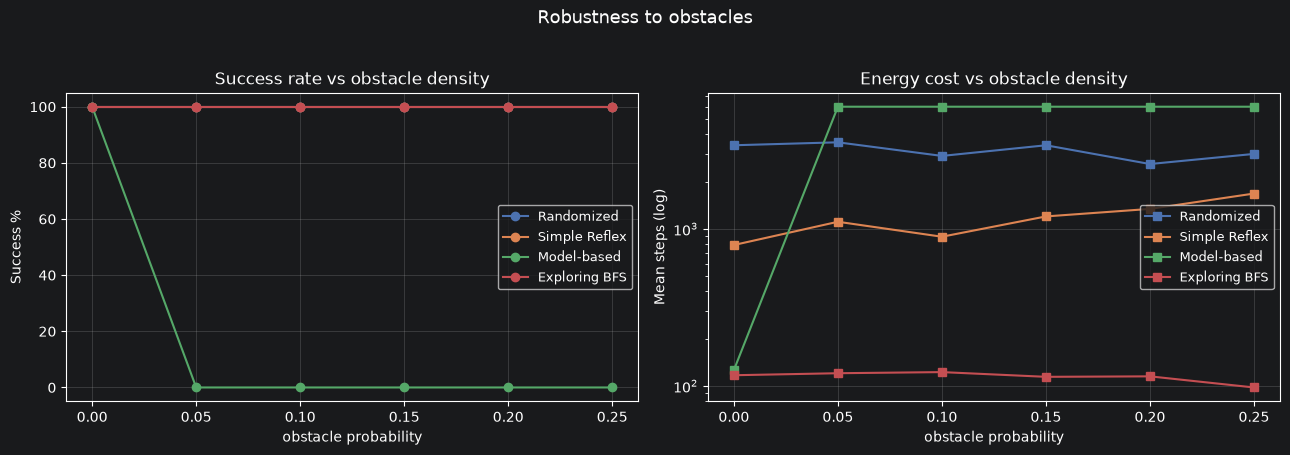

In [100]:
# ============================================================
# BIỂU ĐỒ 2: PERFORMANCE vs MẬT ĐỘ OBSTACLE
# ============================================================
# Sweep p_obstacle để thấy mức độ suy giảm của từng agent.

SWEEP_DENSITIES = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
SWEEP_N = 10
SWEEP_RUNS = 10

SWEEP_AGENTS = [
    "Randomized",
    "Simple Reflex",
    "Model-based",
    "Exploring BFS",
]

def get_sweep_agent(name):
    if name == "Randomized":
        return simple_randomized_agent
    if name == "Simple Reflex":
        return simple_reflex_agent
    if name == "Model-based":
        return make_model_based_agent()
    if name == "Exploring BFS":
        return make_exploring_agent()
    raise ValueError(name)

def max_steps_sweep(name, n):
    cells = n * n
    if name == "Randomized":
        return max(20_000, 400 * cells)
    if name == "Simple Reflex":
        return max(20_000, 300 * cells)
    return max(5_000, 60 * cells)   # Model-based & Exploring BFS

rows = []
for dens in SWEEP_DENSITIES:
    for name in SWEEP_AGENTS:
        succ, steps_list = [], []
        for run in range(SWEEP_RUNS):
            agent = get_sweep_agent(name)
            res = obstacle_vacuum_environment(
                agent, n=SWEEP_N, p=0.2, p_obstacle=dens,
                max_steps=max_steps_sweep(name, SWEEP_N),
                seed=run, verbose=False
            )
            succ.append(res["success"])
            steps_list.append(res["steps"])

        rows.append({
            "Density": dens,
            "Agent": name,
            "Success %": 100.0 * np.mean(succ),
            "Mean steps": np.mean(steps_list),
        })
    print(f"density = {dens:.2f} done", flush=True)

df_sweep = pd.DataFrame(rows)

# ---------------- Vẽ ----------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
colors = {"Randomized": "#4C72B0", "Simple Reflex": "#DD8452",
          "Model-based": "#55A868", "Exploring BFS": "#C44E52"}

for name in SWEEP_AGENTS:
    sub = df_sweep[df_sweep["Agent"] == name].sort_values("Density")
    axes[0].plot(sub["Density"], sub["Success %"], marker="o",
                 color=colors[name], label=name)
    axes[1].plot(sub["Density"], sub["Mean steps"], marker="s",
                 color=colors[name], label=name)

axes[0].set_xlabel("obstacle probability")
axes[0].set_ylabel("Success %")
axes[0].set_title("Success rate vs obstacle density")
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("obstacle probability")
axes[1].set_ylabel("Mean steps (log)")
axes[1].set_yscale("log")
axes[1].set_title("Energy cost vs obstacle density")
axes[1].grid(alpha=0.3)

axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)

plt.suptitle("Robustness to obstacles", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

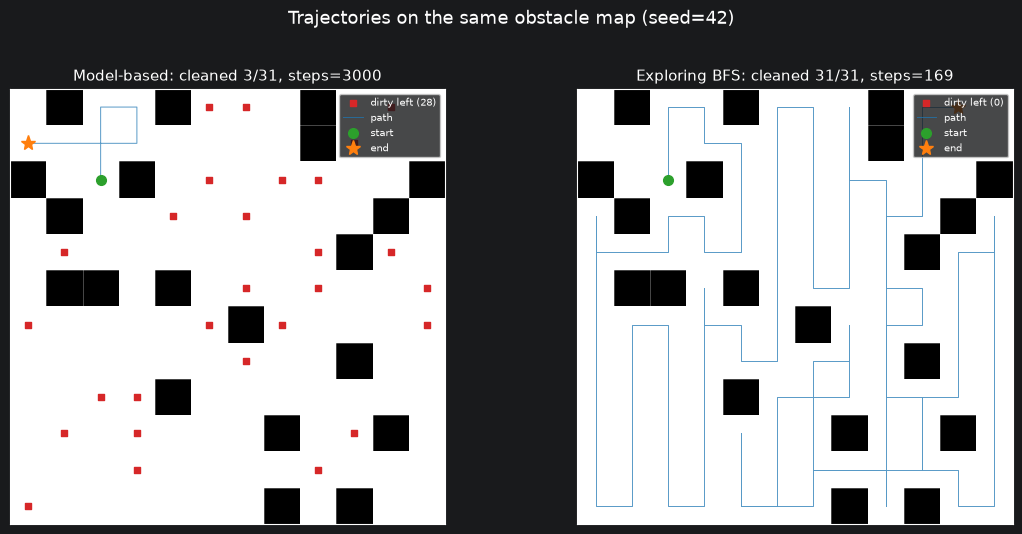

In [101]:
# ============================================================
# BIỂU ĐỒ 3: TRAJECTORY MAP (CÙNG 1 MAP, CÙNG SEED)
# ============================================================
# Cho thấy rõ vì sao model-based bỏ sót vùng sau obstacle,
# còn exploring BFS phủ kín toàn bộ vùng reachable.

def plot_trajectory(ax, trace, obstacles, title):
    """Vẽ obstacle (đen), ô bẩn còn sót (đỏ), quỹ đạo (xanh)."""
    n = obstacles.shape[0]

    ax.imshow(obstacles, cmap="Greys", vmin=0, vmax=1,
              interpolation="nearest")

    # Ô bẩn còn lại sau khi kết thúc
    dr, dc = np.where(trace["room"] == 1)
    ax.scatter(dc, dr, s=20, color="#d62728", marker="s",
               label=f"dirty left ({len(dr)})")

    path = np.array(trace["positions"])
    ax.plot(path[:, 1], path[:, 0], "-", lw=0.7,
            color="#1f77b4", alpha=0.75, label="path")
    ax.plot(path[0, 1], path[0, 0], "o", ms=7,
            color="#2ca02c", label="start")
    ax.plot(path[-1, 1], path[-1, 0], "*", ms=11,
            color="#ff7f0e", label="end")

    ax.set_title(title, fontsize=11)
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", lw=0.4, alpha=0.5)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.legend(fontsize=7, loc="upper right")


# Tạo MỘT map cố định để so sánh công bằng
room0, obs0, start0 = make_room_with_obstacles(
    n=12, p_dirty=0.2, p_obstacle=0.15, seed=42
)

trace_agents = ["Model-based", "Exploring BFS"]
traces = {}
for name in trace_agents:
    agent = get_sweep_agent(name)
    traces[name] = run_with_trace(agent, room0, obs0, start0, max_steps=3000)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.4))
for ax, name in zip(axes, trace_agents):
    tr = traces[name]
    cleaned = tr["initial_dirty"] - tr["remaining_dirty"]
    plot_trajectory(
        ax, tr, obs0,
        f"{name}: cleaned {cleaned}/{tr['initial_dirty']}, "
        f"steps={tr['steps']}"
    )

plt.suptitle("Trajectories on the same obstacle map (seed=42)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

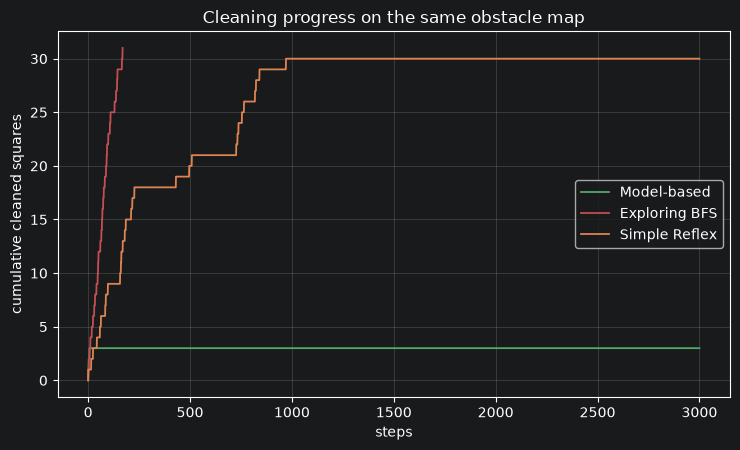

In [102]:
# ============================================================
# BIỂU ĐỒ 4: CLEANING PROGRESS (CUMULATIVE CLEANED vs STEPS)
# ============================================================
# Đường nào lên nhanh và chạm trần = agent phủ tốt.
# Đường nằm ngang sớm = agent bỏ cuộc / kẹt sau obstacle.

# Thêm Simple Reflex vào để thấy rõ sự tương phản
traces["Simple Reflex"] = run_with_trace(
    simple_reflex_agent, room0, obs0, start0, max_steps=3000
)

plt.figure(figsize=(7.5, 4.6))

for name, tr in traces.items():
    cleaned = tr["initial_dirty"] - np.array(tr["remaining"])
    plt.plot(cleaned, lw=1.3, color=colors.get(name, "#7f7f7f"), label=name)

plt.xlabel("steps")
plt.ylabel("cumulative cleaned squares")
plt.title("Cleaning progress on the same obstacle map")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Nhận xét về môi trường có obstacle

- **Randomized Agent** vẫn tránh được obstacle nhờ bumper, nhưng di chuyển
  ngẫu nhiên nên rất chậm và dễ không hoàn thành trong `max_steps`.

- **Simple Reflex Agent** tốt hơn randomized agent vì không cố đi vào tường,
  nhưng vẫn thiếu chiến lược khám phá toàn cục.

- **Model-based Reflex Agent gốc** không phù hợp với obstacle vì chiến lược
  quét hình rắn giả định phòng là hình chữ nhật đầy đủ. Obstacle có thể
  làm agent bỏ sót nhiều vùng.

- **Exploring BFS Agent** hoạt động tốt hơn vì nó xây dựng bản đồ nội bộ,
  biết ô nào đã thăm, ô nào bị chặn, và luôn dùng BFS để đi tới ô chưa
  thăm gần nhất.

## Kết luận tổng thể

Bài tập này đã triển khai và so sánh ba loại reflex-based agents trong
môi trường vacuum-cleaner world:

1. **Simple Randomized Agent**: Baseline, không rational, hiệu năng kém nhất.
2. **Simple Reflex Agent**: Phản ứng với cảm biến nhưng không có chiến lược,
   hiệu năng trung bình.
3. **Model-based Reflex Agent**: Duy trì trạng thái nội bộ, quét có hệ thống,
   hiệu năng vượt trội (~30-70x tốt hơn).

**Bài học rút ra:**
- Việc duy trì model (trạng thái nội bộ) giúp agent lập kế hoạch có hệ thống,
  tránh lặp lại hành động vô ích.
- Tuy nhiên, model-based agent kém robust hơn khi môi trường không đúng
  giả thiết (obstacles, cảm biến nhiễu).
- Multi-pass scanning là giải pháp đơn giản nhưng hiệu quả để xử lý
  dirt sensor noise.
- Frontier-based exploration (BFS) là chiến lược phù hợp cho môi trường
  không biết trước.